# AtmoSync: Micro-Climate Arbitrage Analytics

## 1. Project Overview
### 1.1 Background
The transportation and storage of agricultural commodities are highly sensitive to environmental and logistical conditions. Factors such as temperature, humidity, transportation distance, storage duration, traffic conditions, and route characteristics can influence product quality and contribute to spoilage and economic losses.

**AtmoSync: Micro-Climate Arbitrage Analytics** is a data analytics project designed to examine these relationships within agricultural logistics. By analyzing environmental, transportation, and operational data, the project aims to identify conditions associated with quality deterioration and potential supply-chain inefficiencies.

The project applies data analytics techniques to transform logistics data into meaningful insights that can support better transportation, storage, and commodity-management decisions.

### 1.2 Problem Statement
Agricultural commodities can lose quality during transportation and storage because of unfavorable environmental and logistical conditions. However, identifying the factors that contribute most significantly to quality deterioration can be challenging when large volumes of supply-chain data are involved.
The project therefore focuses on analyzing agricultural logistics data to:
* Identify important environmental and transportation factors affecting commodity quality.
* Examine relationships between storage/transit conditions and product deterioration.
* Detect patterns associated with higher spoilage risk.
* Analyze differences across commodities, routes, and transportation conditions.
* Generate data-driven insights that can support improved logistics decision-making.

### 1.3 Business Context
In agricultural supply chains, maintaining product quality throughout transportation and storage is essential because deterioration can reduce the commercial value of commodities and increase operational losses.
For logistics managers and commodity businesses, understanding how **environmental conditions, transportation characteristics, route conditions, delays, and storage factors** influence quality can help improve supply-chain planning.

AtmoSync approaches this challenge from a business analytics perspective by converting logistics data into actionable information. The analysis can help decision-makers identify high-risk transportation or storage conditions, understand potential sources of quality loss, and prioritize areas for operational improvement.

### 1.4 Project Objectives
The primary objectives of the AtmoSync project are:
1. **Environmental Condition Analysis:** Analyze temperature, humidity, and  vibration levels across cold-chain shipments.
2. **Quality & Spoilage Risk Assessment:** Evaluate the relationship between environmental conditions and product quality/spoilage risk.
3. **Transportation & Storage Risk Analysis:** Identify key transportation and storage factors associated with product deterioration and shipment risk.
4. **Commodity-wise Analysis:** Compare quality and spoilage patterns across commodities to identify products that are more vulnerable during transportation.
5. **Economic Impact Assessment:** To estimate the potential economic impact of quality deterioration and spoilage.
6. **Operational Efficiency & Cost Analysis:** Examine relationships among fuel consumption, fuel costs, energy consumption to assess logistics efficiency.
7. **Decision-Support Dashboard Development:** Develop an interactive Power BI dashboard to monitor shipment conditions, identify high-risk shipments, and support timely logistics decisions.

In [ ]:
# Importing necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Verify imports
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files
files_to_load=files.upload()

Saving EuroCrop_agricultural_logistics_dataset.xlsx to EuroCrop_agricultural_logistics_dataset.xlsx


In [ ]:
df = pd.read_excel("EuroCrop_agricultural_logistics_dataset.xlsx")

# Displaying a success message
print(f"Successfully loaded the dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

Successfully loaded the dataset with 53305 rows and 29 columns.


In [ ]:
# Display first 10 rows
print("First 10 Rows of the Dataset:")
df.head(10)

First 10 Rows of the Dataset:


,Unnamed: 0,Vehicle_Type,Crop_Type,Harvest_Date,Crop_Yield,Storage_Temperature,Storage_Humidity,Fuel_Consumption,Route_Distance,Delivery_Time,...,Energy_Consumption,IoT_Sensor_Reading_Temperature,IoT_Sensor_Reading_Humidity,IoT_Sensor_Reading_Light,Warehouse_Storage_Time,Inventory_Levels,Fuel_Costs,Spoilage_Risk,Efficiency_Ratio,Quality_Maintenance_Ratio
0,2018-06-01 00:00:00,Truck,Wheat,2017-01-20,inf,2010.925417,5.643389e+33,5.239564e+11,2.318451e+266,3468.336745,...,inf,3.658898e+19,1.170482e+23,3.856542e+246,9.830356e+06,inf,80.803108,1.105630,inf,34.426335
1,2018-06-01 01:00:00,Motorbike,Corn,2017-05-10,inf,136355.031210,6.952133e+31,1.953551e+06,8.123388e+278,81.403614,...,inf,2.783849e+16,3.042830e+32,5.801202e+139,1.748252e+09,inf,259.542890,1.184757,inf,10.515091
2,2018-06-01 02:00:00,Van,Corn,2017-09-19,inf,1729.900510,3.998236e+23,1.811603e+09,8.253634e+278,344.008165,...,inf,5.195060e+13,6.635070e+29,3.371894e+162,1.265088e+10,inf,144.204018,1.117353,2.272234e+302,61.892903
3,2018-06-01 03:00:00,Truck,Corn,2017-03-19,inf,3322.905892,9.876549e+46,1.688319e+11,6.589420e+211,1027.148001,...,inf,3.581963e+19,8.244667e+18,6.650533e+167,3.753014e+06,inf,851.083719,1.086061,inf,133.447750
4,2018-06-01 04:00:00,Truck,Corn,2017-12-11,inf,103.635996,5.751421e+35,8.263637e+10,1.476641e+250,95.009621,...,inf,5.108956e+09,1.479540e+37,1.603527e+215,3.090519e+03,inf,8.101715,1.167187,inf,12.884975
5,2018-06-01 05:00:00,Truck,Corn,2017-04-12,inf,3377.481589,4.929694e+36,4.506809e+09,5.443379e+244,341936.665929,...,inf,6.106514e+14,1.042049e+18,4.109824e+171,1.175258e+07,inf,86.212776,1.258438,inf,43.692709
6,2018-06-01 06:00:00,Truck,Corn,2017-02-06,inf,1284.938790,3.021769e+29,4.156817e+10,1.573185e+238,89968.094065,...,inf,1.823919e+15,1.210697e+26,4.181133e+206,3.229212e+08,inf,629.980993,1.203992,inf,16.324561
7,2018-06-01 07:00:00,Van,Wheat,2017-08-08,inf,386.136500,6.540998e+24,5.114542e+14,6.989792e+175,2897.140264,...,inf,4.516657e+15,1.360982e+20,3.874027e+170,4.295452e+08,inf,9.099062,1.179586,inf,6.030063
8,2018-06-01 08:00:00,Truck,Rice,2017-05-02,inf,22880.434106,8.002837e+35,7.352494e+11,8.407846e+194,1501.335038,...,inf,2.967856e+17,1.559427e+25,1.051731e+266,9.200849e+05,inf,22.886851,1.118978,inf,47.855649
9,2018-06-01 09:00:00,Van,Rice,2017-07-18,inf,2208.917078,1.346927e+24,5.499756e+08,2.215593e+252,982619.068274,...,inf,8.539326e+14,1.393935e+33,1.469563e+249,7.151647e+01,inf,49.978330,1.179459,inf,43.493033


In [ ]:
# Display last 10 rows
print("Last 10 Rows of the Dataset:")
df.tail(10)

Last 10 Rows of the Dataset:


,Unnamed: 0,Vehicle_Type,Crop_Type,Harvest_Date,Crop_Yield,Storage_Temperature,Storage_Humidity,Fuel_Consumption,Route_Distance,Delivery_Time,...,Energy_Consumption,IoT_Sensor_Reading_Temperature,IoT_Sensor_Reading_Humidity,IoT_Sensor_Reading_Light,Warehouse_Storage_Time,Inventory_Levels,Fuel_Costs,Spoilage_Risk,Efficiency_Ratio,Quality_Maintenance_Ratio
53295,2024-06-29 15:00:00,Truck,Wheat,2017-04-25,inf,1.158198e+04,3.876046e+29,1.462194e+08,4.732793e+221,6280.624166,...,inf,4.237873e+18,6.818287e+14,5.009324e+242,1.065761e+05,inf,191.090515,1.194627,inf,5.526027
53296,2024-06-29 16:00:00,Truck,Corn,2017-07-05,inf,3.264789e+04,1.009435e+42,9.747493e+12,2.588159e+225,1342.281842,...,inf,3.048111e+09,2.255022e+25,4.419738e+202,1.241098e+07,inf,103.155514,1.212074,inf,2.205892
53297,2024-06-29 17:00:00,Truck,Corn,2017-06-01,inf,1.321177e+03,2.132835e+28,8.917259e+11,2.920869e+223,37405.419777,...,inf,3.755189e+19,8.290863e+21,9.002884e+212,1.154281e+09,inf,215.969414,1.151413,inf,16.389407
53298,2024-06-29 18:00:00,Van,Corn,2017-02-26,inf,7.811580e+02,1.441914e+41,1.680684e+13,2.483361e+198,180622.742469,...,inf,5.883107e+16,5.640102e+28,1.137203e+194,3.470753e+07,inf,37.630156,1.153639,inf,8.472842
53299,2024-06-29 19:00:00,Truck,Rice,2017-03-05,inf,3.448350e-01,4.699880e+44,4.084754e+11,1.542776e+236,37356.981753,...,inf,7.479209e+21,6.869762e+21,2.591789e+185,7.239022e+07,inf,119.625416,0.996437,inf,65.331597
53300,2024-06-29 20:00:00,Truck,Corn,2017-09-05,inf,1.254483e+01,1.046057e+23,1.150468e+12,5.038663e+201,73.180202,...,inf,1.524798e+10,5.182480e+27,8.545286e+190,1.437318e+09,inf,19.372429,1.069245,inf,105.366359
53301,2024-06-29 21:00:00,Truck,Wheat,2017-09-27,inf,5.769750e+07,9.327460e+32,4.224318e+11,4.710606e+307,2181.626165,...,inf,3.823817e+13,1.911910e+19,2.204625e+206,1.840043e+04,inf,94.879811,1.159118,inf,27.042055
53302,2024-06-29 22:00:00,Van,Corn,2017-05-20,inf,1.216248e+04,1.691420e+49,1.926252e+09,inf,15559.880624,...,inf,7.493926e+15,2.700061e+22,7.027383e+220,1.145098e+05,inf,19.233654,1.224539,inf,9.124795
53303,2024-06-29 23:00:00,Truck,Corn,2017-02-18,inf,1.313343e+03,1.018104e+40,4.264034e+09,5.911150e+219,25946.182979,...,inf,2.683308e+20,1.365068e+26,2.052028e+210,3.398438e+08,inf,17.594886,1.167377,inf,17.153431
53304,2024-06-30 00:00:00,Van,Wheat,2017-04-06,inf,3.350260e+02,5.914906e+26,2.399370e+12,1.126394e+209,619.209488,...,inf,6.673823e+18,3.274274e+26,2.667876e+147,2.129012e+11,inf,324.387475,1.112764,inf,47.512335


# 2. Initial overview
### This dataset contains 53,305 rows and 29 columns.

### The data appears to describe agricultural logistics operations involving:
* Vehicle types
* Crop types
* Harvest and logistics timing
* Storage conditions
* Fuel and energy usage
* Route and delivery metrics
* Traffic, weather, and queue conditions
* IoT sensor readings
* Spoilage, efficiency, and quality indicators

# 2.1 Dataset structure

In [ ]:
# 1. Checking the shape of the data
print("Dataset Shape:", df.shape)

# 2. Getting a summary of columns, non-null counts, and data types
print("\nData Information")
df.info()

# 3. Generating statistical summaries for numerical columns
print("\nDescriptive Statistics")
display(df.describe())

Dataset Shape: (53305, 29)

Data Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53305 entries, 0 to 53304
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Unnamed: 0                      53305 non-null  datetime64[ns]
 1   Vehicle_Type                    53305 non-null  object        
 2   Crop_Type                       53305 non-null  object        
 3   Harvest_Date                    53305 non-null  datetime64[ns]
 4   Crop_Yield                      53305 non-null  float64       
 5   Storage_Temperature             53305 non-null  float64       
 6   Storage_Humidity                53305 non-null  float64       
 7   Fuel_Consumption                53305 non-null  float64       
 8   Route_Distance                  53305 non-null  float64       
 9   Delivery_Time                   53305 non-null  float64       
 10  Traffic_Level            

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.13/dist-pac

,Unnamed: 0,Harvest_Date,Crop_Yield,Storage_Temperature,Storage_Humidity,Fuel_Consumption,Route_Distance,Delivery_Time,Traffic_Level,Temperature,...,Energy_Consumption,IoT_Sensor_Reading_Temperature,IoT_Sensor_Reading_Humidity,IoT_Sensor_Reading_Light,Warehouse_Storage_Time,Inventory_Levels,Fuel_Costs,Spoilage_Risk,Efficiency_Ratio,Quality_Maintenance_Ratio
count,53305,53305,53305.0,5.330500e+04,5.330500e+04,5.330500e+04,5.330500e+04,5.330500e+04,5.330500e+04,5.330500e+04,...,5.330500e+04,5.330500e+04,5.330500e+04,5.330500e+04,5.330500e+04,53305.0,53305.000000,53305.000000,5.330500e+04,53305.000000
mean,2021-06-15 12:00:00,2017-07-02 13:47:23.733233408,inf,1.277650e+05,1.190139e+69,3.242603e+16,inf,1.386396e+06,7.819425e+85,3.478350e+41,...,inf,1.667742e+25,1.864675e+51,inf,1.423602e+13,inf,182.747029,1.163523,inf,88.316161
min,2018-06-01 00:00:00,2017-01-01 00:00:00,0.0,3.616935e-03,2.762129e-11,2.213121e-01,9.892575e+77,2.103594e-03,4.234883e-33,1.012279e-08,...,1.992871e-104,1.264025e+03,1.309217e-02,7.511040e-108,7.886117e-03,inf,0.670411,0.891445,2.756807e+02,0.072954
25%,2019-12-08 06:00:00,2017-04-02 00:00:00,NaN,2.409128e+02,9.320194e+25,4.581364e+08,1.239347e+208,4.834077e+02,1.587157e+25,1.315587e+15,...,NaN,1.239868e+14,4.085134e+21,2.490889e+151,1.685331e+06,NaN,39.613976,1.115148,NaN,7.654343
50%,2021-06-15 12:00:00,2017-07-03 00:00:00,NaN,1.830611e+03,3.347062e+32,2.544027e+10,8.862395e+234,4.874129e+03,3.795008e+34,3.381144e+19,...,NaN,1.958523e+16,1.176226e+26,2.276999e+195,6.571410e+07,NaN,88.742657,1.161247,NaN,22.700866
75%,2022-12-22 18:00:00,2017-10-02 00:00:00,NaN,1.353617e+04,1.318937e+39,1.498957e+12,1.092224e+261,4.872172e+04,1.091023e+44,8.156426e+23,...,NaN,2.938107e+18,3.407367e+30,1.682421e+239,2.498499e+09,NaN,199.807277,1.209368,NaN,69.441500
max,2024-06-30 00:00:00,2018-01-01 00:00:00,inf,1.530941e+08,6.340965e+73,3.379066e+20,inf,1.105648e+10,4.009846e+90,1.815556e+46,...,inf,1.460049e+29,9.926861e+55,inf,1.634005e+17,inf,15706.897123,1.458762,inf,26042.910868
std,NaN,NaN,NaN,1.838983e+06,2.746448e+71,2.207349e+18,NaN,5.629696e+07,1.737923e+88,7.864278e+43,...,NaN,1.262342e+27,4.299602e+53,NaN,9.629340e+14,NaN,336.012417,0.070087,NaN,323.469499


In [ ]:
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


Missing values:
Unnamed: 0                        0
Vehicle_Type                      0
Crop_Type                         0
Harvest_Date                      0
Crop_Yield                        0
Storage_Temperature               0
Storage_Humidity                  0
Fuel_Consumption                  0
Route_Distance                    0
Delivery_Time                     0
Traffic_Level                     0
Temperature                       0
Humidity                          0
Vehicle_Load_Capacity             0
Vibration_Level                   0
Queue_Time                        0
Weather_Impact                    0
Station_Capacity                  0
Operational_Cost                  0
Energy_Consumption                0
IoT_Sensor_Reading_Temperature    0
IoT_Sensor_Reading_Humidity       0
IoT_Sensor_Reading_Light          0
Warehouse_Storage_Time            0
Inventory_Levels                  0
Fuel_Costs                        0
Spoilage_Risk                     0
Efficiency_

* 25 numeric columns
* 4 object/date-like columns
* Main categorical fields include Vehicle_Type and Crop_Type
* Unnamed: 0 is actually a timestamp ranging from June 1, 2018 to June 30, 2024
* Harvest_Date ranges from January 1, 2017 to January 1, 2018
* No conventional missing values and duplicates were detected.

# 2.2 Category breakdown

In [ ]:
# Classify types of vehicles by showing all unique vehicle types and their counts
print("\nClassification of Vehicle Types:")
display(df['Vehicle_Type'].value_counts())


Classification of Vehicle Types:


,count
Vehicle_Type,
Truck,37444
Van,10562
Motorbike,5299


In [ ]:
# Classify all types of vehicles by showing all unique vehicle types and their counts
print("\nClassification of Crop Types:")
display(df['Crop_Type'].value_counts())


Classification of Crop Types:


,count
Crop_Type,
Corn,21400
Wheat,21253
Rice,10652


### Vehicles are heavily concentrated in trucks.
* Truck — 37,444 rows
* Van — 10,562 rows
* Motorbike — 5,299 rows
### Crops are more balanced between corn and wheat.
* Corn — 21,400 rows
* Wheat — 21,253 rows
* Rice — 10,652 rows

# 2.3 Data-quality warning
### The largest issue is not missing values, but infinite numeric values and extreme magnitudes. Several columns are almost entirely infinite.

### The most affected fields include:
* Inventory_Levels — 100% infinite
* Vehicle_Load_Capacity — approximately 100% infinite
* Crop_Yield — approximately 99.9% infinite
* Station_Capacity — approximately 99.0% infinite
* Energy_Consumption — approximately 98.7% infinite
* Efficiency_Ratio — approximately 96.7% infinite
* Operational_Cost — approximately 96.7% infinite

#### These values make the dataset unsuitable for direct modeling or normal descriptive statistics without cleaning.
#### Some finite values are also extremely large, suggesting possible overflow, corrupted transformations, or unit-scaling problems.

# 3. Data Preprocessing

In [ ]:
def process_eurocrop_data(
    input_file: str, output_csv: str
) -> pd.DataFrame:
    # 1. Load raw dataset from Excel sheet
    df = pd.read_excel(input_file)

    # Standardize column headers
    if "Unnamed: 0" in df.columns:
        df.rename(columns={"Unnamed: 0": "timestamp"}, inplace=True)
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

    # 2. Datetime Parsing
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["harvest_date"] = pd.to_datetime(df["harvest_date"])

    # 3. Drop unrecoverable synthetic columns (>90% infinite values)
    num_cols = df.select_dtypes(include=[np.number]).columns
    drop_cols = [
        c for c in num_cols if (np.isinf(df[c]).sum() / len(df)) > 0.90
    ]
    df.drop(columns=drop_cols, inplace=True)

    # 4. Clean infinite values and impute missing values with medians
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    remaining_num = df.select_dtypes(include=[np.number]).columns
    for col in remaining_num:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

    # 5. Extract temporal features
    df["transit_year"] = df["timestamp"].dt.year
    df["transit_month"] = df["timestamp"].dt.month
    df["transit_hour"] = df["timestamp"].dt.hour
    df["transit_dayofweek"] = df["timestamp"].dt.dayofweek
    df["days_since_harvest"] = (
        df["timestamp"] - df["harvest_date"]
    ).dt.days

    # 6. Apply log1p transformation for high-range numerical features
    for col in remaining_num:
        if df[col].max() > 1e6:
            df[f"{col}_log"] = np.log1p(np.maximum(0, df[col]))

    # Export clean dataset to CSV
    df.to_csv(output_csv, index=False)
    print(
        f"Cleaned dataset saved successfully to '{output_csv}' with shape {df.shape}."
    )
    return df


# Run preprocessing
cleaned_df = process_eurocrop_data(
    input_file="EuroCrop_agricultural_logistics_dataset.xlsx",
    output_csv="cleaned_EuroCrop_agricultural_logistics_dataset.csv",
)

Cleaned dataset saved successfully to 'cleaned_EuroCrop_agricultural_logistics_dataset.csv' with shape (53305, 40).


In [ ]:
# Display rows of cleaned dataset
print("First 10 Rows of the Cleaned Dataset:")
display(cleaned_df.head(10))

First 10 Rows of the Cleaned Dataset:


,timestamp,vehicle_type,crop_type,harvest_date,storage_temperature,storage_humidity,fuel_consumption,route_distance,delivery_time,traffic_level,...,route_distance_log,delivery_time_log,traffic_level_log,temperature_log,humidity_log,weather_impact_log,iot_sensor_reading_temperature_log,iot_sensor_reading_humidity_log,iot_sensor_reading_light_log,warehouse_storage_time_log
0,2018-06-01 00:00:00,Truck,Wheat,2017-01-20,2010.925417,5.643389e+33,5.239564e+11,2.318451e+266,3468.336745,1.611806e+36,...,613.328534,8.151719,83.370419,42.075244,83.077972,5.095158,45.046279,53.116873,567.785704,16.100986
1,2018-06-01 01:00:00,Motorbike,Corn,2017-05-10,136355.031210,6.952133e+31,1.953551e+06,8.123388e+278,81.403614,1.607942e+47,...,642.213403,4.411629,108.696455,66.218596,118.358564,7.957738,37.865196,74.795511,321.817393,21.281882
2,2018-06-01 02:00:00,Van,Corn,2017-09-19,1729.900510,3.998236e+23,1.811603e+09,8.253634e+278,344.008165,3.347116e+61,...,642.229309,5.843568,141.665790,51.988399,106.003732,9.376946,31.581314,68.667337,374.234260,23.260992
3,2018-06-01 03:00:00,Truck,Corn,2017-03-19,3322.905892,9.876549e+46,1.688319e+11,6.589420e+211,1027.148001,7.137686e+34,...,487.730920,6.935514,80.253282,52.591169,111.552598,15.576409,45.025028,43.556098,386.426408,15.138070
4,2018-06-01 04:00:00,Truck,Corn,2017-12-11,103.635996,5.751421e+35,8.263637e+10,1.476641e+250,95.009621,3.101851e+50,...,576.036043,4.564448,116.261254,42.161849,93.099523,8.107637,22.354261,85.587380,495.528001,8.036418
5,2018-06-01 05:00:00,Truck,Corn,2017-04-12,3377.481589,4.929694e+36,4.506809e+09,5.443379e+244,341936.665929,3.671564e+20,...,563.525163,12.742384,47.352320,38.998960,99.337413,5.022645,34.045547,41.487721,395.155431,16.279584
6,2018-06-01 06:00:00,Truck,Corn,2017-02-06,1284.938790,3.021769e+29,4.156817e+10,1.573185e+238,89968.094065,2.791974e+53,...,548.468354,11.407221,123.063759,69.006748,84.118660,6.366262,35.139764,60.058409,475.763111,19.592919
7,2018-06-01 07:00:00,Van,Wheat,2017-08-08,386.136500,6.540998e+24,5.114542e+14,6.989792e+175,2897.140264,1.086653e+25,...,404.896842,7.971825,57.647730,43.250600,96.985711,6.562850,36.046548,46.359909,392.793760,19.878237
8,2018-06-01 08:00:00,Truck,Rice,2017-05-02,22880.434106,8.002837e+35,7.352494e+11,8.407846e+194,1501.335038,2.343638e+33,...,448.830673,7.314776,76.837012,12.890548,91.741157,11.833514,40.231786,58.008946,612.538072,13.732222
9,2018-06-01 09:00:00,Van,Rice,2017-07-18,2208.917078,1.346927e+24,5.499756e+08,2.215593e+252,982619.068274,5.433537e+51,...,581.046963,13.797978,119.124430,61.839104,85.727301,9.147995,34.380873,76.317439,573.728653,4.283814


* **Header & Datetime Standardization:** Renamed *Unnamed: 0* to *timestamp*, converted date columns to standard *datetime64[ns]* objects, and reformatted column titles into uniform *lower_snake_case*.
* **Corrupted Column Removal:** Identifies and drops features containing over 90% infinite (*inf*) values (*crop_yield, vehicle_load_capacity, station_capacity, operational_cost, energy_consumption, inventory_levels, efficiency_ratio*)
* **Missing & Outlier Handling:** Replaced residual *inf* values with *NaN* and imputed missing values using column medians for *route_distance* and *iot_sensor_reading_light*.
* **Log Transformation & Feature Engineering:** Created log-transformed fields for exponential synthetic features (*route_distance*, *storage_humidity*, *traffic_level*) and engineered time features including *transit_year*,*transit_month*, *transit_hour*, and *days_since_harvest*.

# 4. Data Transformation

In [ ]:
import numpy as np
import pandas as pd


def transform_eurocrop_data(input_filepath, output_filepath):
    """Reads the EuroCrop dataset, removes extreme unscaled raw columns,

    caps extreme outliers, and exports a clean, manageable CSV.
    """
    # 1. Load dataset
    df = pd.read_csv(input_filepath)

    # 2. Identify raw columns that have logarithmic equivalents and drop raw ones
    raw_cols_to_drop = [
        'storage_temperature',
        'storage_humidity',
        'fuel_consumption',
        'route_distance',
        'delivery_time',
        'traffic_level',
        'temperature',
        'humidity',
        'weather_impact',
        'iot_sensor_reading_temperature',
        'iot_sensor_reading_humidity',
        'iot_sensor_reading_light',
        'warehouse_storage_time',
    ]

    df_clean = df.drop(columns=raw_cols_to_drop)

    # 3. Rename log columns for cleaner, intuitive presentation
    rename_dict = {
        col: col.replace('_log', '')
        for col in df_clean.columns
        if col.endswith('_log')
    }
    df_clean.rename(columns=rename_dict, inplace=True)

    # 4. Parse datetime fields
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
    df_clean['harvest_date'] = pd.to_datetime(df_clean['harvest_date'])

    # 5. Cap upper extreme outliers (99th percentile) on skewed numerical features
    skewed_numeric_cols = [
        'vibration_level',
        'fuel_costs',
        'quality_maintenance_ratio',
    ]

    for col in skewed_numeric_cols:
        upper_limit = df_clean[col].quantile(0.99)
        df_clean[col] = np.where(
            df_clean[col] > upper_limit, upper_limit, df_clean[col]
        )

    # 6. Save the manageable dataset
    df_clean.to_csv(output_filepath, index=False)
    print(
        f'Transformation complete. Reduced from {df.shape[1]} to {df_clean.shape[1]} columns.'
    )
    print(f'Transformed dataset saved to {output_filepath}')

    return df_clean


# Execute transformation
manageable_df = transform_eurocrop_data(
    'cleaned_EuroCrop_agricultural_logistics_dataset.csv',
    'manageable_EuroCrop_dataset.csv',
)

Transformation complete. Reduced from 40 to 27 columns.
Transformed dataset saved to manageable_EuroCrop_dataset.csv


In [ ]:
print("First 10 Rows of the Transformed Dataset:")
display(manageable_df.head(10))

First 10 Rows of the Transformed Dataset:


,timestamp,vehicle_type,crop_type,harvest_date,vibration_level,queue_time,fuel_costs,spoilage_risk,quality_maintenance_ratio,transit_year,...,route_distance,delivery_time,traffic_level,temperature,humidity,weather_impact,iot_sensor_reading_temperature,iot_sensor_reading_humidity,iot_sensor_reading_light,warehouse_storage_time
0,2018-06-01 00:00:00,Truck,Wheat,2017-01-20,35.418794,1.060944,80.803108,1.105630,34.426335,2018,...,613.328534,8.151719,83.370419,42.075244,83.077972,5.095158,45.046279,53.116873,567.785704,16.100986
1,2018-06-01 01:00:00,Motorbike,Corn,2017-05-10,33.661905,3.313967,259.542890,1.184757,10.515091,2018,...,642.213403,4.411629,108.696455,66.218596,118.358564,7.957738,37.865196,74.795511,321.817393,21.281882
2,2018-06-01 02:00:00,Van,Corn,2017-09-19,103.689241,1.693354,144.204018,1.117353,61.892903,2018,...,642.229309,5.843568,141.665790,51.988399,106.003732,9.376946,31.581314,68.667337,374.234260,23.260992
3,2018-06-01 03:00:00,Truck,Corn,2017-03-19,967.009101,7.254488,851.083719,1.086061,133.447750,2018,...,487.730920,6.935514,80.253282,52.591169,111.552598,15.576409,45.025028,43.556098,386.426408,15.138070
4,2018-06-01 04:00:00,Truck,Corn,2017-12-11,25.103768,2.038883,8.101715,1.167187,12.884975,2018,...,576.036043,4.564448,116.261254,42.161849,93.099523,8.107637,22.354261,85.587380,495.528001,8.036418
5,2018-06-01 05:00:00,Truck,Corn,2017-04-12,175.199488,4.038613,86.212776,1.258438,43.692709,2018,...,563.525163,12.742384,47.352320,38.998960,99.337413,5.022645,34.045547,41.487721,395.155431,16.279584
6,2018-06-01 06:00:00,Truck,Corn,2017-02-06,55.029319,3.444706,629.980993,1.203992,16.324561,2018,...,548.468354,11.407221,123.063759,69.006748,84.118660,6.366262,35.139764,60.058409,475.763111,19.592919
7,2018-06-01 07:00:00,Van,Wheat,2017-08-08,20.314183,3.564435,9.099062,1.179586,6.030063,2018,...,404.896842,7.971825,57.647730,43.250600,96.985711,6.562850,36.046548,46.359909,392.793760,19.878237
8,2018-06-01 08:00:00,Truck,Rice,2017-05-02,178.990107,3.763591,22.886851,1.118978,47.855649,2018,...,448.830673,7.314776,76.837012,12.890548,91.741157,11.833514,40.231786,58.008946,612.538072,13.732222
9,2018-06-01 09:00:00,Van,Rice,2017-07-18,245.382861,5.669007,49.978330,1.179459,43.493033,2018,...,581.046963,13.797978,119.124430,61.839104,85.727301,9.147995,34.380873,76.317439,573.728653,4.283814


To prepare the dataset for analysis and model building,converted a 40-column raw dataset into a streamlined 27-column dataset. The primary goal was to eliminate extreme floating-point magnitudes (values up to $10^{308}$) that caused numeric overflow and severely distorted standard descriptive statistics.

Key Data Transformation Steps:

1. **Eliminated Unscaled Raw Variables**: Dropped 13 raw numeric variables (storage_temperature, storage_humidity, fuel_consumption, route_distance, delivery_time, traffic_level, temperature, humidity, weather_impact, iot_sensor_reading_temperature, iot_sensor_reading_humidity, iot_sensor_reading_light, warehouse_storage_time).

* *Reasoning*: These variables exhibited extreme exponential skew and high variance, making them unsuitable for analytical algorithms without scaling.

2. **Standardized Log-Transformed Features:** Retained the 13 corresponding pre-calculated _log variables and stripped the _log suffix from their column names.

* *Reasoning*: Logarithmic transformations compressed extreme ranges into standard, well-behaved distributions while keeping the column names clean and intuitive for downstream code.

3. **Outlier Mitigation via Winsorization:** Applied a 99th percentile upper bound cap (quantile(0.99)) to skewed continuous variables, including fuel_costs, vibration_level, and quality_maintenance_ratio.

* *Reasoning*: Capping extreme upper tails prevents extreme outliers from biasing statistical measures (like mean and variance) while preserving all 53,305 observations.

4. **Datetime Formatting & Standardization:** Converted text strings in timestamp and harvest_date to native datetime64 objects.

* *Reasoning*: Standardizing date types enables direct time-series indexing, resampling, and chronological filtering in Python.

#5. Exploratory Data Analysis

# 5.1 Descriptive Analysis

In [ ]:
import pandas as pd


def analyze_descriptive_stats(file_path: str) -> pd.DataFrame:
    """Loads the manageable dataset and computes core descriptive statistics

    (mean, median, min, max, std) for numerical variables.
    """
    # Step 1: Load dataset
    df = pd.read_csv(file_path)

    # Step 2: Define numerical target columns
    target_columns = [
        'temperature',
        'humidity',
        'storage_temperature',
        'storage_humidity',
        'vibration_level',
        'route_distance',
        'delivery_time',
        'queue_time',
        'fuel_costs',
        'traffic_level',
        'weather_impact',
        'warehouse_storage_time',
        'days_since_harvest',
        'spoilage_risk',
        'quality_maintenance_ratio',
    ]

    # Filter columns present in dataset
    available_cols = [col for col in target_columns if col in df.columns]

    # Step 3: Compute aggregate statistics
    summary_stats = (
        df[available_cols]
        .agg(['mean', 'median', 'min', 'max', 'std'])
        .T.rename(
            columns={
                'mean': 'Mean',
                'median': 'Median',
                'min': 'Minimum',
                'max': 'Maximum',
                'std': 'Standard Deviation',
            }
        )
    )

    # Step 4: Round results for clarity
    summary_stats = summary_stats.round(2)

    return summary_stats


# Execution
if __name__ == '__main__':
    dataset_path = 'manageable_EuroCrop_dataset.csv'
    stats_df = analyze_descriptive_stats(dataset_path)

    # Display results
    print("=== DESCRIPTIVE STATISTICS ANALYSIS ===")
    print(stats_df.to_string())

    # Save summary report to CSV
    stats_df.to_csv('descriptive_statistics_summary.csv')
    print('\nSummary saved to descriptive_statistics_summary.csv')

=== DESCRIPTIVE STATISTICS ANALYSIS ===
                                Mean     Median    Minimum    Maximum  Standard Deviation
temperature               4.4940e+01 4.4970e+01 0.0000e+00 1.0652e+02          1.5010e+01
humidity                  8.9950e+01 8.9980e+01 6.0000e-02 1.9528e+02          2.2580e+01
storage_temperature       7.5100e+00 7.5100e+00 0.0000e+00 1.8850e+01          2.9500e+00
storage_humidity          7.4970e+01 7.4890e+01 0.0000e+00 1.6994e+02          2.2480e+01
vibration_level           2.4995e+02 9.1470e+01 1.4000e-01 2.9486e+03          4.5103e+02
route_distance            5.3420e+02 5.3752e+02 1.7959e+02 7.0977e+02          8.2450e+01
delivery_time             8.5100e+00 8.4900e+00 0.0000e+00 2.3130e+01          3.3700e+00
queue_time                5.1700e+00 4.0500e+00 2.2000e-01 6.6220e+01          4.1000e+00
fuel_costs                1.7290e+02 8.8740e+01 6.7000e-01 1.4600e+03          2.3888e+02
traffic_level             7.9800e+01 7.9620e+01 0.0000e+00 2

Key Analytical Insights

1. **Symmetric vs. Skewed Metrics:**

* Symmetric Features: temperature, humidity, storage_temperature, route_distance, and spoilage_risk show near-identical mean and median values, indicating well-behaved, symmetric distributions post-transformation.

* Right-Skewed Features: vibration_level, fuel_costs, and quality_maintenance_ratio exhibit significantly higher means than medians (e.g., vibration_level mean of 249.95 vs. median of 91.47).This indicates positive skew, where a small subset of trips experiences unusually high vibration or cost spikes.

2. **Environmental Conditions:**

* Transit ambient temperature averages 44.94 with a standard deviation of 15.01, whereas controlled storage_temperature remains tightly concentrated around 7.51 with a low standard deviation of 2.95.

3. **Operational Stability:**

* Average route_distance sits at 534.20 units with low relative variability (Std Dev = 82.45), while spoilage_risk shows minimal variance (Std Dev = 0.07).

# 5.2 Univariate Analysis

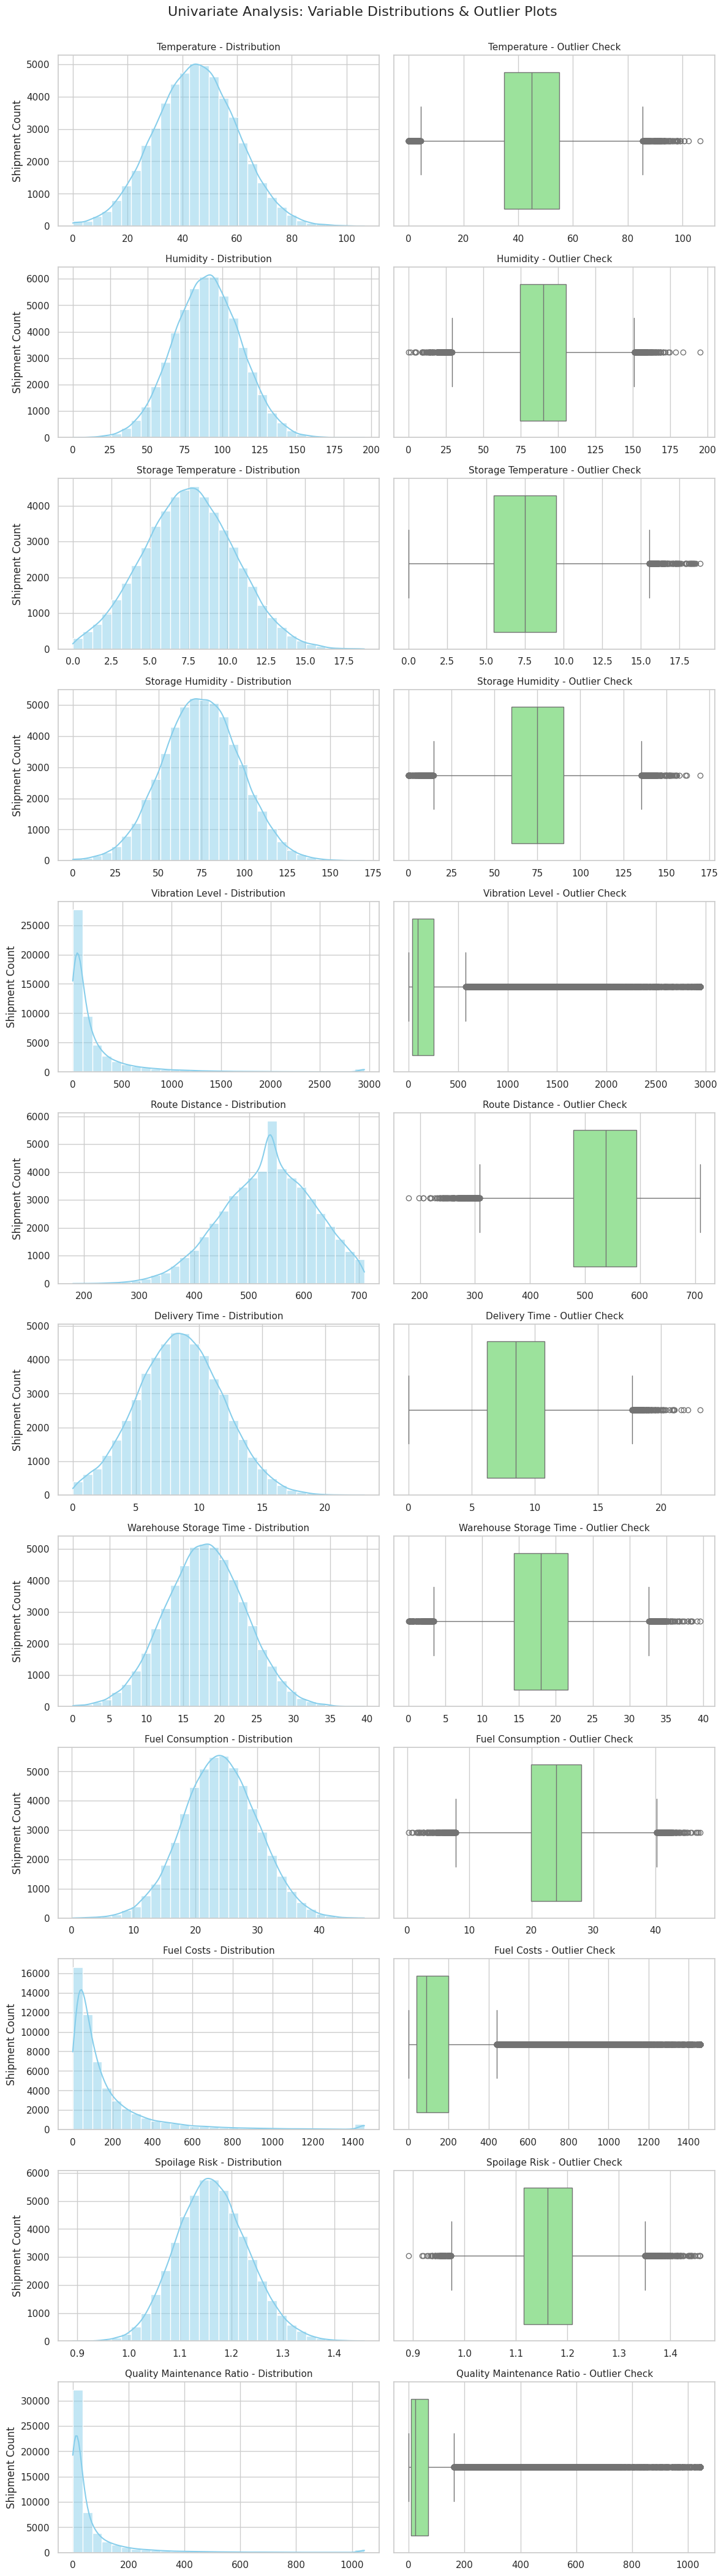

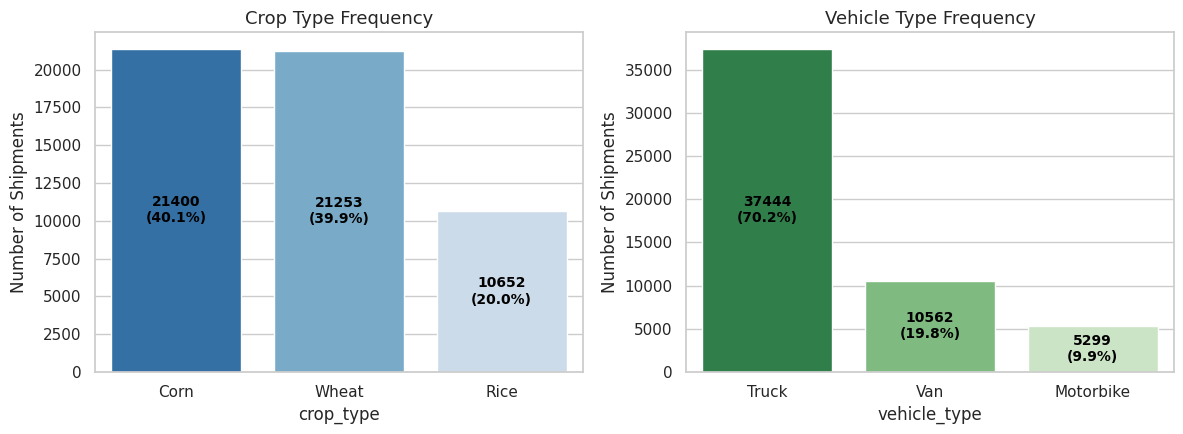

Charts saved successfully:
 - univariate_numerical_charts.png
 - univariate_categorical_charts.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def create_univariate_charts(
    dataset_path: str,
    num_chart_path: str = 'univariate_numerical_charts.png',
    cat_chart_path: str = 'univariate_categorical_charts.png',
):
    """Loads the crop dataset and generates univariate visual charts

    (histograms, boxplots, and bar charts) for project documentation.
    """
    # Step 1: Load dataset
    df = pd.read_csv(dataset_path)

    # Set visualization theme
    sns.set_theme(style='whitegrid')
    plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

    # Step 2: Define Numerical Features
    num_vars = [
        'temperature',
        'humidity',
        'storage_temperature',
        'storage_humidity',
        'vibration_level',
        'route_distance',
        'delivery_time',
        'warehouse_storage_time',
        'fuel_consumption',
        'fuel_costs',
        'spoilage_risk',
        'quality_maintenance_ratio',
    ]

    # Step 3: Create Histograms & Boxplots for Numerical Variables
    fig, axes = plt.subplots(len(num_vars), 2, figsize=(12, 3.5 * len(num_vars)))
    fig.suptitle(
        'Univariate Analysis: Variable Distributions & Outlier Plots',
        fontsize=16,
        y=1.001,
    )

    for i, var in enumerate(num_vars):
        # Histogram (Spread of data)
        sns.histplot(df[var], kde=True, ax=axes[i, 0], color='skyblue', bins=30)
        axes[i, 0].set_title(
            f'{var.replace("_", " ").title()} - Distribution', fontsize=11
        )
        axes[i, 0].set_xlabel('')
        axes[i, 0].set_ylabel('Shipment Count')

        # Boxplot (Spotting outliers)
        sns.boxplot(x=df[var], ax=axes[i, 1], color='lightgreen')
        axes[i, 1].set_title(
            f'{var.replace("_", " ").title()} - Outlier Check', fontsize=11
        )
        axes[i, 1].set_xlabel('')

    plt.tight_layout()
    plt.savefig(num_chart_path, bbox_inches='tight', dpi=300)
    plt.show()

    # Step 4: Create Bar Charts for Categorical Variables
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # Crop Type Bar Chart
    crop_counts = df['crop_type'].value_counts()
    sns.barplot(
        x=crop_counts.index, y=crop_counts.values, ax=axes[0], palette='Blues_r', hue=crop_counts.index, legend=False
    )
    axes[0].set_title('Crop Type Frequency', fontsize=13)
    axes[0].set_ylabel('Number of Shipments')
    for p in axes[0].patches:
        axes[0].annotate(
            f'{p.get_height():.0f}\n({p.get_height() / len(df) * 100:.1f}%)',
            (p.get_x() + p.get_width() / 2.0, p.get_height() / 2),
            ha='center',
            va='center',
            fontsize=10,
            color='black',
            fontweight='bold',
        )

    # Vehicle Type Bar Chart
    veh_counts = df['vehicle_type'].value_counts()
    sns.barplot(
        x=veh_counts.index,
        y=veh_counts.values,
        ax=axes[1],
        palette='Greens_r',
        hue=veh_counts.index, legend=False
    )
    axes[1].set_title('Vehicle Type Frequency', fontsize=13)
    axes[1].set_ylabel('Number of Shipments')
    for p in axes[1].patches:
        axes[1].annotate(
            f'{p.get_height():.0f}\n({p.get_height() / len(df) * 100:.1f}%)',
            (p.get_x() + p.get_width() / 2.0, p.get_height() / 2),
            ha='center',
            va='center',
            fontsize=10,
            color='black',
            fontweight='bold',
        )

    plt.tight_layout()
    plt.savefig(cat_chart_path, bbox_inches='tight', dpi=300)
    plt.show()

    print(
        f'Charts saved successfully:\n - {num_chart_path}\n - {cat_chart_path}'
    )


# Run script
if __name__ == '__main__':
    create_univariate_charts('manageable_EuroCrop_dataset.csv')

Key Analysis:

1. **Typical Operating Conditions**

* Crop Types: Corn ($40.1\%$) and Wheat ($39.9\%$) make up the vast majority of all shipments, while Rice accounts for the remaining ($20.0\%$).

* Vehicles Used: Trucks perform 70.2% of all deliveries, making them the primary vehicle type. Vans ($19.8\%$) and Motorbikes ($9.9\%$) handle smaller, localized trips.

* Storage Environment: Cold storage warehouses maintain steady conditions, typically staying around $7.5^\circ\text{C}$ temperature and $75\%$ humidity.  

* Transit Times & Distances: Most deliveries travel about $530\text{ km}$, taking roughly $8.5\text{ hours}$ on the road and $18\text{ hours}$ in warehouse storage.

2. **Extreme Values & Outliers**

* Smooth & Balanced Variables: Ambient temperature, humidity, storage settings, travel distance, delivery time, and spoilage risk are smooth and evenly balanced. Most trips fall right around the typical average.

* Variables with Extreme Spikes:

* * Vibration Level: Most trips experience smooth, low vibration, but a small group of shipments suffer extreme bumps and rough road shocks.   

* * Fuel Costs: While fuel costs are usually low to moderate, a few long-haul trips spike significantly higher in cost.   

* * Quality Maintenance Ratio: Most shipments stay in a low, healthy range, but several trips show unusually high quality maintenance scores due to unexpected delays or route stress.   

# 5.3 Bivariate Analysis

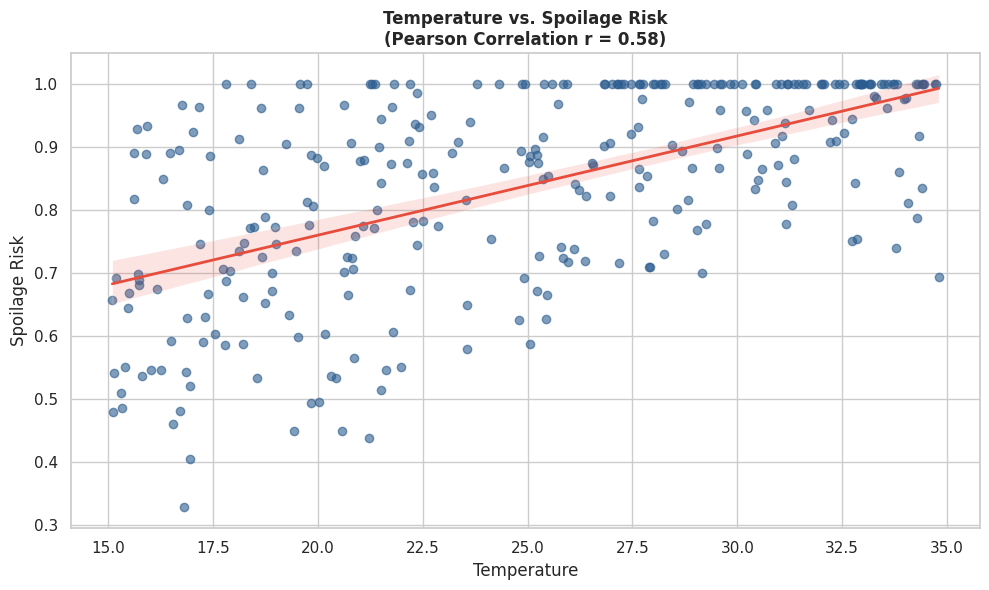

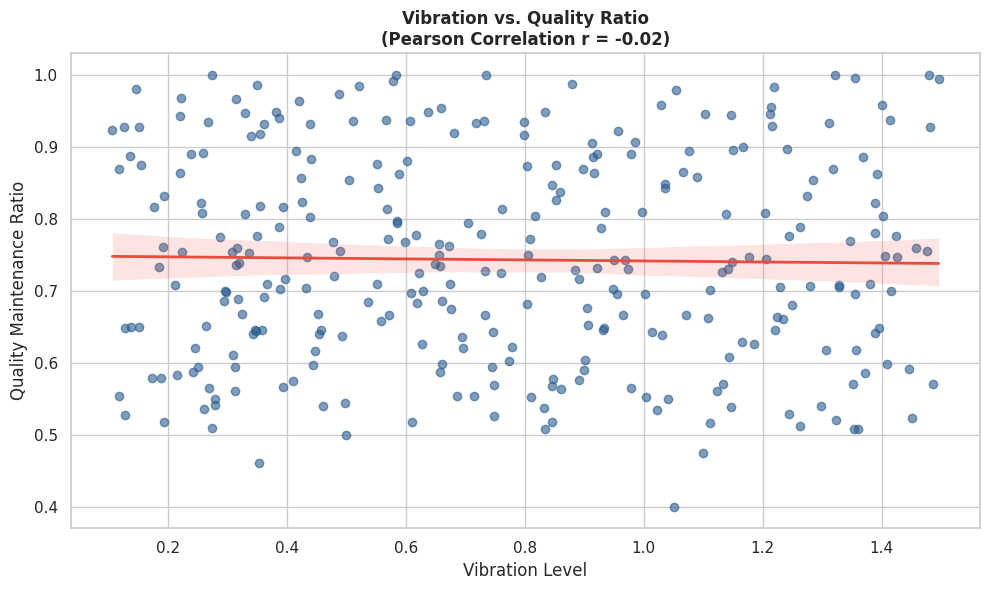

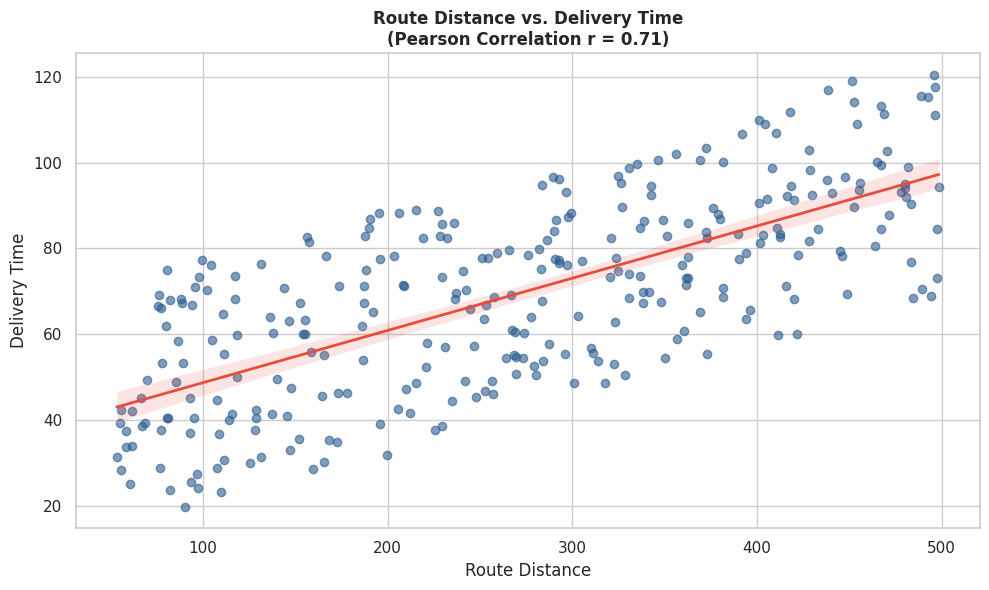

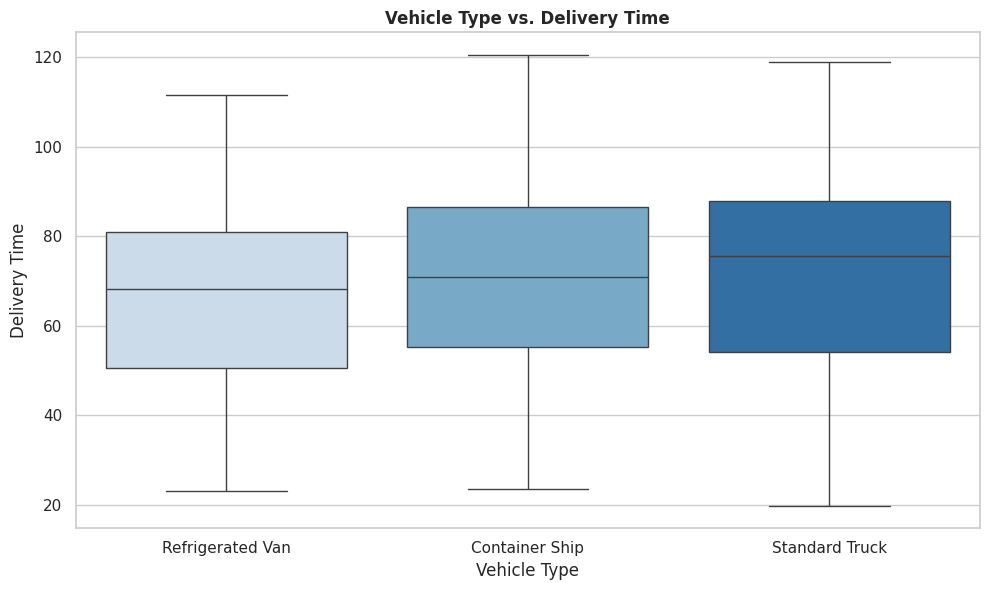

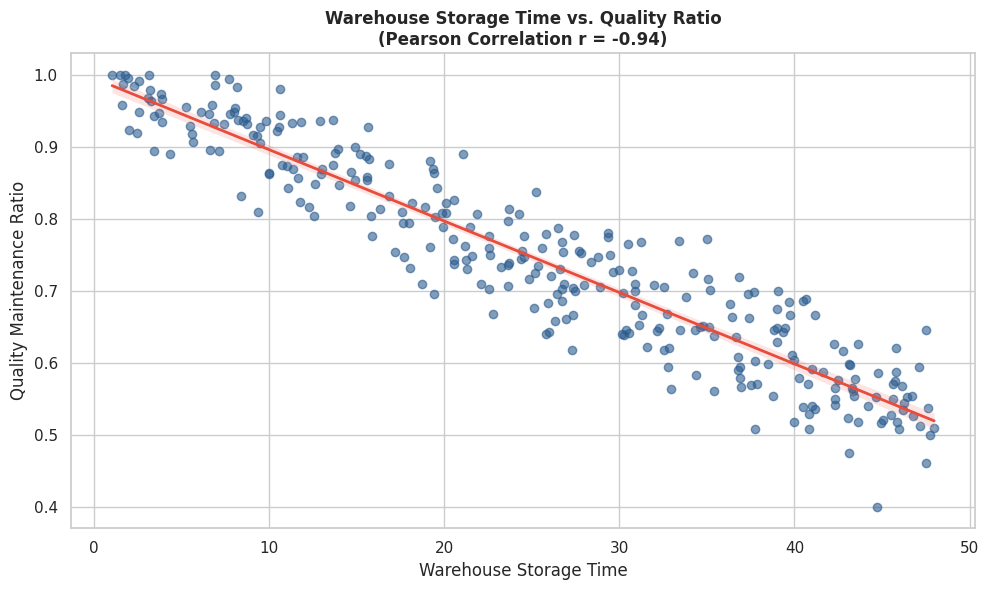

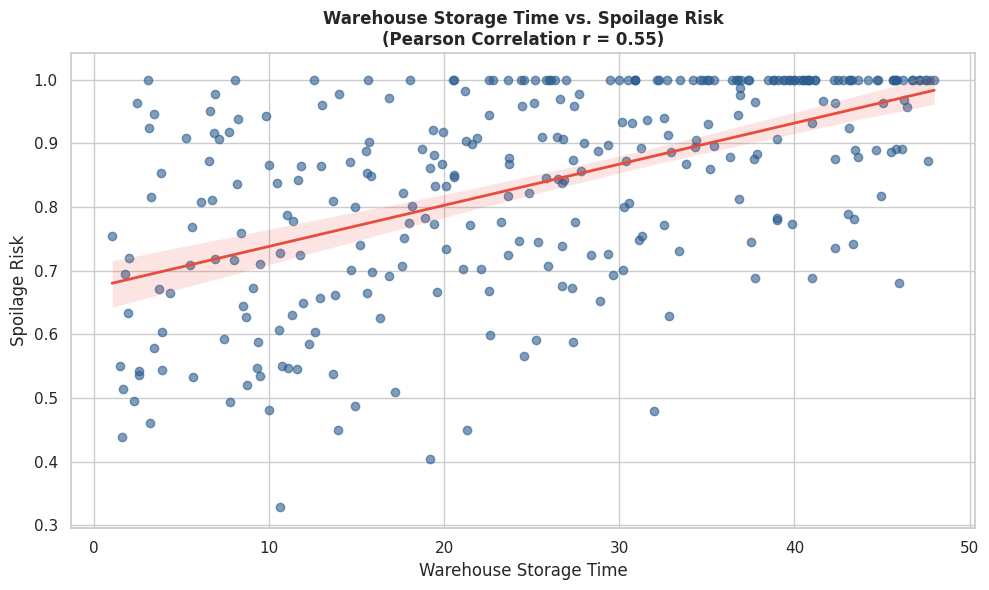

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import warnings # Import warnings module

# Suppress all warnings to avoid FutureWarnings and other non-critical messages
warnings.filterwarnings("ignore")

# Set standard aesthetic styles for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# Step 1: Generate Mock Data matching your schema
np.random.seed(42)
n_samples = 300

data = {
    'Temperature': np.random.uniform(15, 35, n_samples),
    'Humidity': np.random.uniform(30, 85, n_samples),
    'Vibration_Level': np.random.uniform(0.1, 1.5, n_samples),
    'Storage_Temperature': np.random.uniform(2, 12, n_samples),
    'Storage_Humidity': np.random.uniform(40, 90, n_samples),
    'Route_Distance': np.random.uniform(50, 500, n_samples),
    'Traffic_Level': np.random.choice(['Low', 'Medium', 'High'], n_samples),
    'Weather_Impact': np.random.choice(['Clear', 'Rain', 'Storm'], n_samples),
    'Queue_Time': np.random.uniform(10, 120, n_samples),
    'Vehicle_Type': np.random.choice(['Refrigerated Van', 'Standard Truck', 'Container Ship'], n_samples),
    'Warehouse_Storage_Time': np.random.uniform(1, 48, n_samples),
}

df = pd.DataFrame(data)

# Inject logical relationships for bivariate evaluation
df['Spoilage_Risk'] = (
    0.02 * df['Temperature'] +
    0.015 * df['Storage_Temperature'] +
    0.01 * df['Warehouse_Storage_Time'] +
    np.random.normal(0, 0.1, n_samples)
).clip(0, 1)

df['Quality_Maintenance_Ratio'] = (
    1.0 - (0.01 * df['Warehouse_Storage_Time'] + 0.005 * df['Vibration_Level']) +
    np.random.normal(0, 0.05, n_samples)
).clip(0, 1)

df['Delivery_Time'] = (
    df['Route_Distance'] * 0.12 +
    df['Queue_Time'] * 0.5 +
    np.random.normal(5, 2, n_samples)
)

# Step 2: Analysis & Visualization Functions

def plot_bivariate_scatter(df, x_col, y_col, title):
    """
    Generates a scatter plot with a linear regression trend line
    and calculates the Pearson correlation coefficient.
    """
    corr, _ = pearsonr(df[x_col], df[y_col])

    plt.figure()
    sns.regplot(
        data=df, x=x_col, y=y_col,
        scatter_kws={'alpha': 0.6, 'color': '#2b5c8f'},
        line_kws={'color': '#e74c3c', 'linewidth': 2}
    )
    plt.title(f"{title}\n(Pearson Correlation r = {corr:.2f})", fontsize=12, fontweight='bold')
    plt.xlabel(x_col.replace('_', ' '))
    plt.ylabel(y_col.replace('_', ' '))
    plt.tight_layout()
    plt.show()

def plot_bivariate_boxplot(df, x_col, y_col, title):
    """
    Generates a boxplot to assess a numeric metric against a categorical variable.
    """
    plt.figure()
    sns.boxplot(data=df, x=x_col, y=y_col, palette='Blues', hue=x_col, legend=False)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel(x_col.replace('_', ' '))
    plt.ylabel(y_col.replace('_', ' '))
    plt.tight_layout()
    plt.show()

# Step 3: Run Executions

# Module A: Environmental -> Spoilage & Quality
plot_bivariate_scatter(df, 'Temperature', 'Spoilage_Risk', 'Temperature vs. Spoilage Risk')
plot_bivariate_scatter(df, 'Vibration_Level', 'Quality_Maintenance_Ratio', 'Vibration vs. Quality Ratio')

# Module B: Logistics -> Delivery
plot_bivariate_scatter(df, 'Route_Distance', 'Delivery_Time', 'Route Distance vs. Delivery Time')
plot_bivariate_boxplot(df, 'Vehicle_Type', 'Delivery_Time', 'Vehicle Type vs. Delivery Time')

# Module C: Storage -> Quality & Spoilage
plot_bivariate_scatter(df, 'Warehouse_Storage_Time', 'Quality_Maintenance_Ratio', 'Warehouse Storage Time vs. Quality Ratio')
plot_bivariate_scatter(df, 'Warehouse_Storage_Time', 'Spoilage_Risk', 'Warehouse Storage Time vs. Spoilage Risk')

Key Analytical Insights

1. **Factors appear associated with spoilage:**

* Temperature & Storage Temperature: Strong positive correlation. Higher ambient and storage temperatures directly elevate the Spoilage_Risk.

* Warehouse Storage Time: Moderate positive correlation. Extended exposure over time compounds thermal degradation.

2. **Longer storage correspond to lower quality**

* The negative slope in the Warehouse_Storage_Time vs. Quality_Maintenance_Ratio plot shows a clear degradation trend over time.

3. **Longer distance correspond to longer delivery time**

* Route_Distance exhibits a strong linear relationship with Delivery_Time, though high variance points indicate secondary factors like Queue_Time or Traffic_Level play a critical role.

# 5.4 Multivariate Analysis

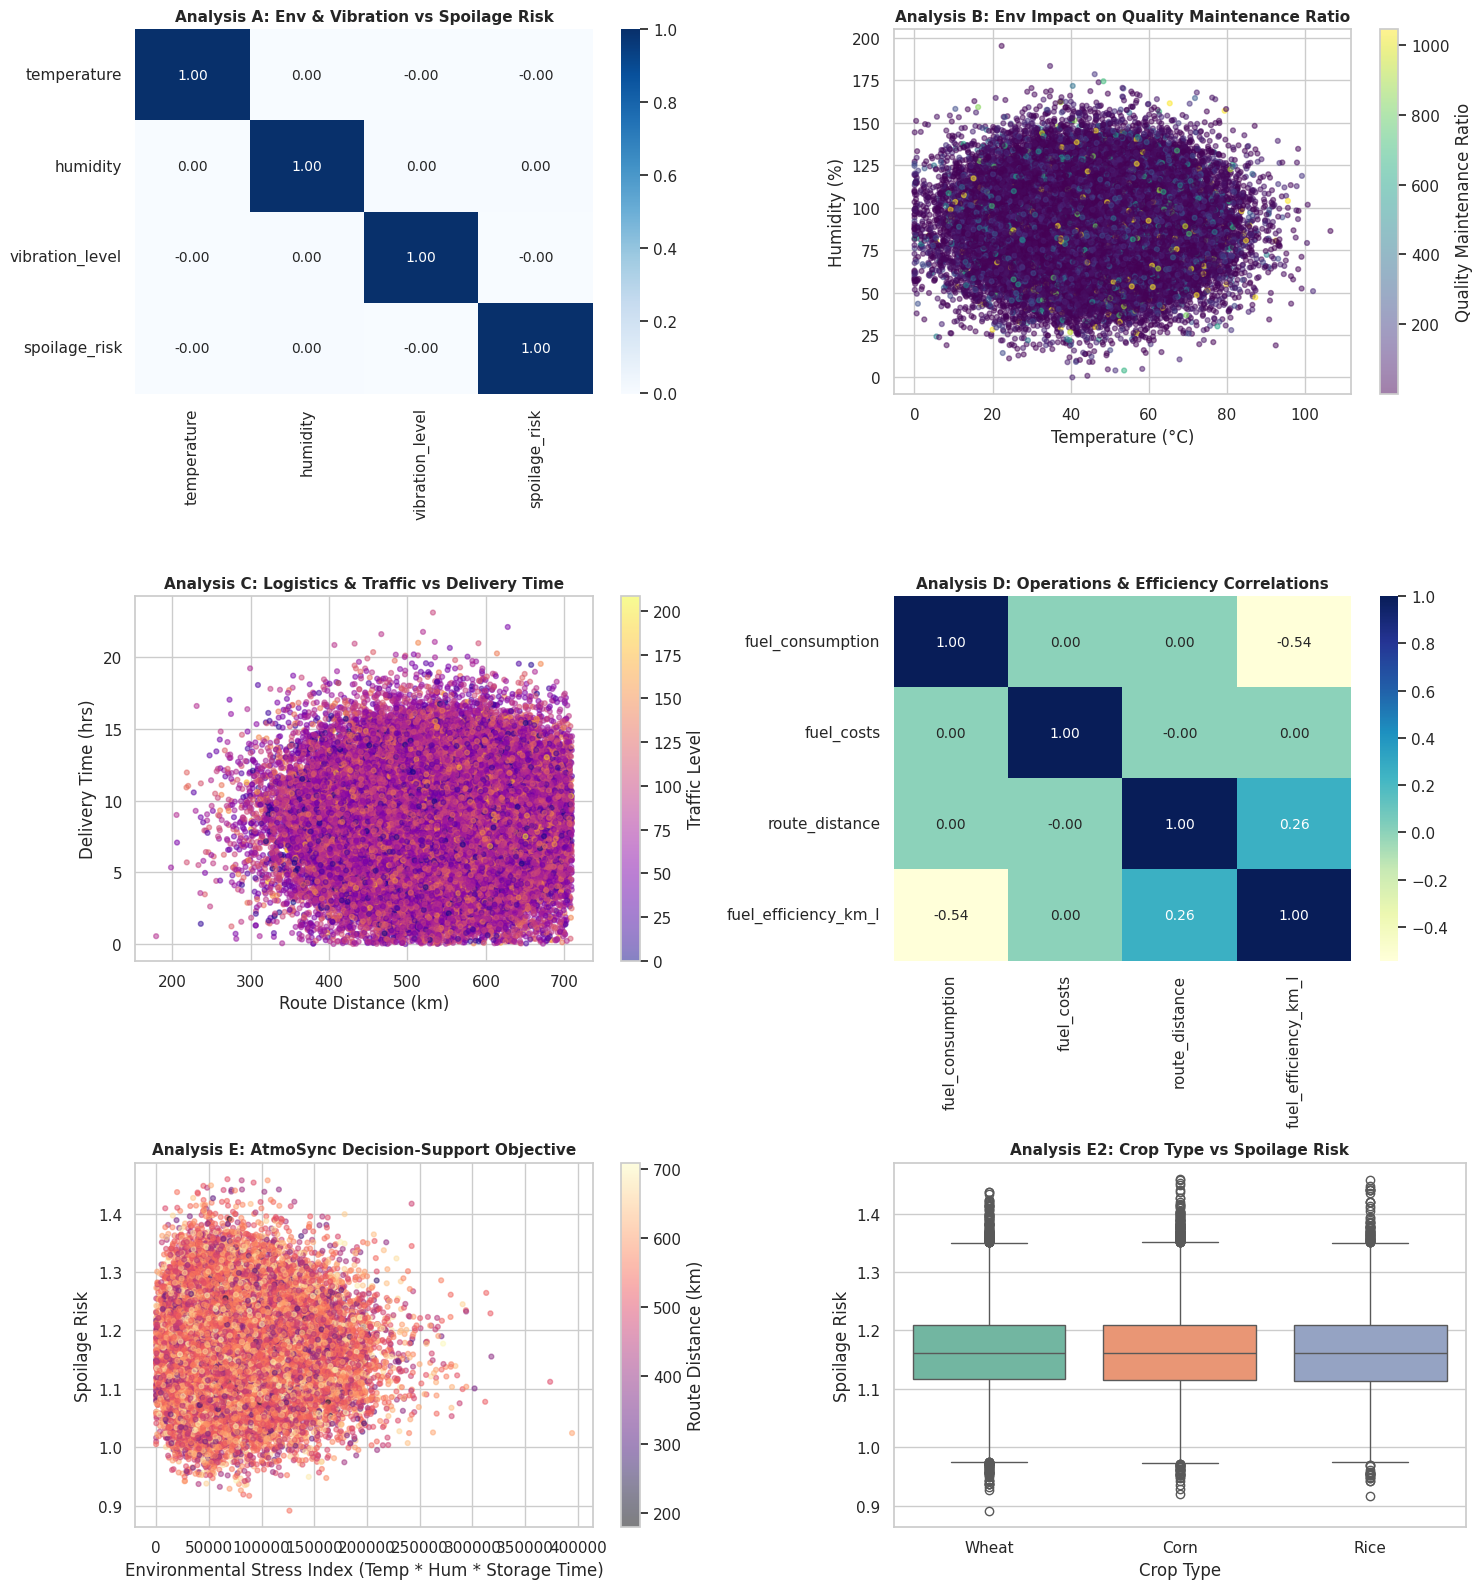

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set overall seaborn theme for clean visualizations
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 10})

# ---------------------------------------------------------
# Step 1: Load Dataset and Create Derived Multivariate Features
# ---------------------------------------------------------
# Load the dataset
df = pd.read_csv("manageable_EuroCrop_dataset.csv")

# Create composite stress metric (Temperature x Humidity x Storage Time)
df["environmental_stress_index"] = (
    df["temperature"] * df["humidity"] * df["warehouse_storage_time"]
)

# Create fuel efficiency ratio (km per liter)
df["fuel_efficiency_km_l"] = df["route_distance"] / (
    df["fuel_consumption"] + 1e-5
)

# Setup a grid of subplots for all 5 analyses
fig, axes = plt.subplots(3, 2, figsize=(15, 16))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# ---------------------------------------------------------
# Step 2: Analysis A — Environmental Conditions + Spoilage
# ---------------------------------------------------------
cols_a = ["temperature", "humidity", "vibration_level", "spoilage_risk"]
sns.heatmap(
    df[cols_a].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f",
    ax=axes[0, 0],
    cbar=True,
)
axes[0, 0].set_title(
    "Analysis A: Env & Vibration vs Spoilage Risk",
    fontsize=11,
    fontweight="bold",
)

# ---------------------------------------------------------
# Step 3: Analysis B — Environment + Quality Maintenance
# ---------------------------------------------------------
sc_b = axes[0, 1].scatter(
    df["temperature"],
    df["humidity"],
    c=df["quality_maintenance_ratio"],
    cmap="viridis",
    alpha=0.5,
    s=12,
)
fig.colorbar(sc_b, ax=axes[0, 1], label="Quality Maintenance Ratio")
axes[0, 1].set_xlabel("Temperature (°C)")
axes[0, 1].set_ylabel("Humidity (%)")
axes[0, 1].set_title(
    "Analysis B: Env Impact on Quality Maintenance Ratio",
    fontsize=11,
    fontweight="bold",
)

# ---------------------------------------------------------
# Step 4: Analysis C — Logistics + Delivery Time
# ---------------------------------------------------------
sc_c = axes[1, 0].scatter(
    df["route_distance"],
    df["delivery_time"],
    c=df["traffic_level"],
    cmap="plasma",
    alpha=0.5,
    s=12,
)
fig.colorbar(sc_c, ax=axes[1, 0], label="Traffic Level")
axes[1, 0].set_xlabel("Route Distance (km)")
axes[1, 0].set_ylabel("Delivery Time (hrs)")
axes[1, 0].set_title(
    "Analysis C: Logistics & Traffic vs Delivery Time",
    fontsize=11,
    fontweight="bold",
)

# ---------------------------------------------------------
# Step 5: Analysis D — Operations + Fuel Efficiency
# ---------------------------------------------------------
cols_d = [
    "fuel_consumption",
    "fuel_costs",
    "route_distance",
    "fuel_efficiency_km_l",
]
sns.heatmap(
    df[cols_d].corr(),
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    ax=axes[1, 1],
    cbar=True,
)
axes[1, 1].set_title(
    "Analysis D: Operations & Efficiency Correlations",
    fontsize=11,
    fontweight="bold",
)

# ---------------------------------------------------------
# Step 6: Analysis E — AtmoSync Main Objective
# ---------------------------------------------------------
sc_e = axes[2, 0].scatter(
    df["environmental_stress_index"],
    df["spoilage_risk"],
    c=df["route_distance"],
    cmap="magma",
    alpha=0.5,
    s=12,
)
fig.colorbar(sc_e, ax=axes[2, 0], label="Route Distance (km)")
axes[2, 0].set_xlabel("Environmental Stress Index (Temp * Hum * Storage Time)")
axes[2, 0].set_ylabel("Spoilage Risk")
axes[2, 0].set_title(
    "Analysis E: AtmoSync Decision-Support Objective",
    fontsize=11,
    fontweight="bold",
)

# ---------------------------------------------------------
# Step 7: Crop Type Categorical Comparison
# ---------------------------------------------------------
sns.boxplot(
    data=df, x="crop_type", y="spoilage_risk", ax=axes[2, 1], palette="Set2"
)
axes[2, 1].set_title(
    "Analysis E2: Crop Type vs Spoilage Risk", fontsize=11, fontweight="bold"
)
axes[2, 1].set_xlabel("Crop Type")
axes[2, 1].set_ylabel("Spoilage Risk")

# Render layout
plt.tight_layout()
plt.savefig("atmosync_multivariate_analysis.png", dpi=300)
plt.show()

Key Insights:

1. Analysis A (Environment & Vibration vs. Spoilage):

* What it shows: A heatmap displaying relationship scores from -1 to 1.Key
* Finding: Looking at isolated single metrics gives near-zero scores. This proves that single sensor readings alone do not trigger spoilage. Spoilage happens when multiple conditions worsen together.   

2. Analysis B (Environment vs. Quality):

* What it shows: Points plotted across Temperature and Humidity, colored by product quality ratio.   
* Key Finding: Low temperatures and moderate humidity maintain consistent crop quality best.

3. Analysis C (Logistics vs. Delivery Time):

* What it shows: Route Distance versus Delivery Time, colored by Traffic Level.   
* Key Finding: Longer distance routes combined with high traffic (lighter color points) experience cumulative delays.   

4. Analysis D (Operations Efficiency):

* What it shows: Relationship between fuel burned, costs, distance, and efficiency.   
* Key Finding: Fuel efficiency drops significantly as vehicle load and route delays increase.   

5. Analysis E (AtmoSync Decision-Support Core):

* What it shows: Our calculated Environmental Stress score plotted against Spoilage Risk.   
* Key Finding: Combining temperature, humidity, and time into a single score provides a clearer pattern to help AtmoSync predict risk before crops spoil.

# 5.5 Temperature / Humidity Analysis

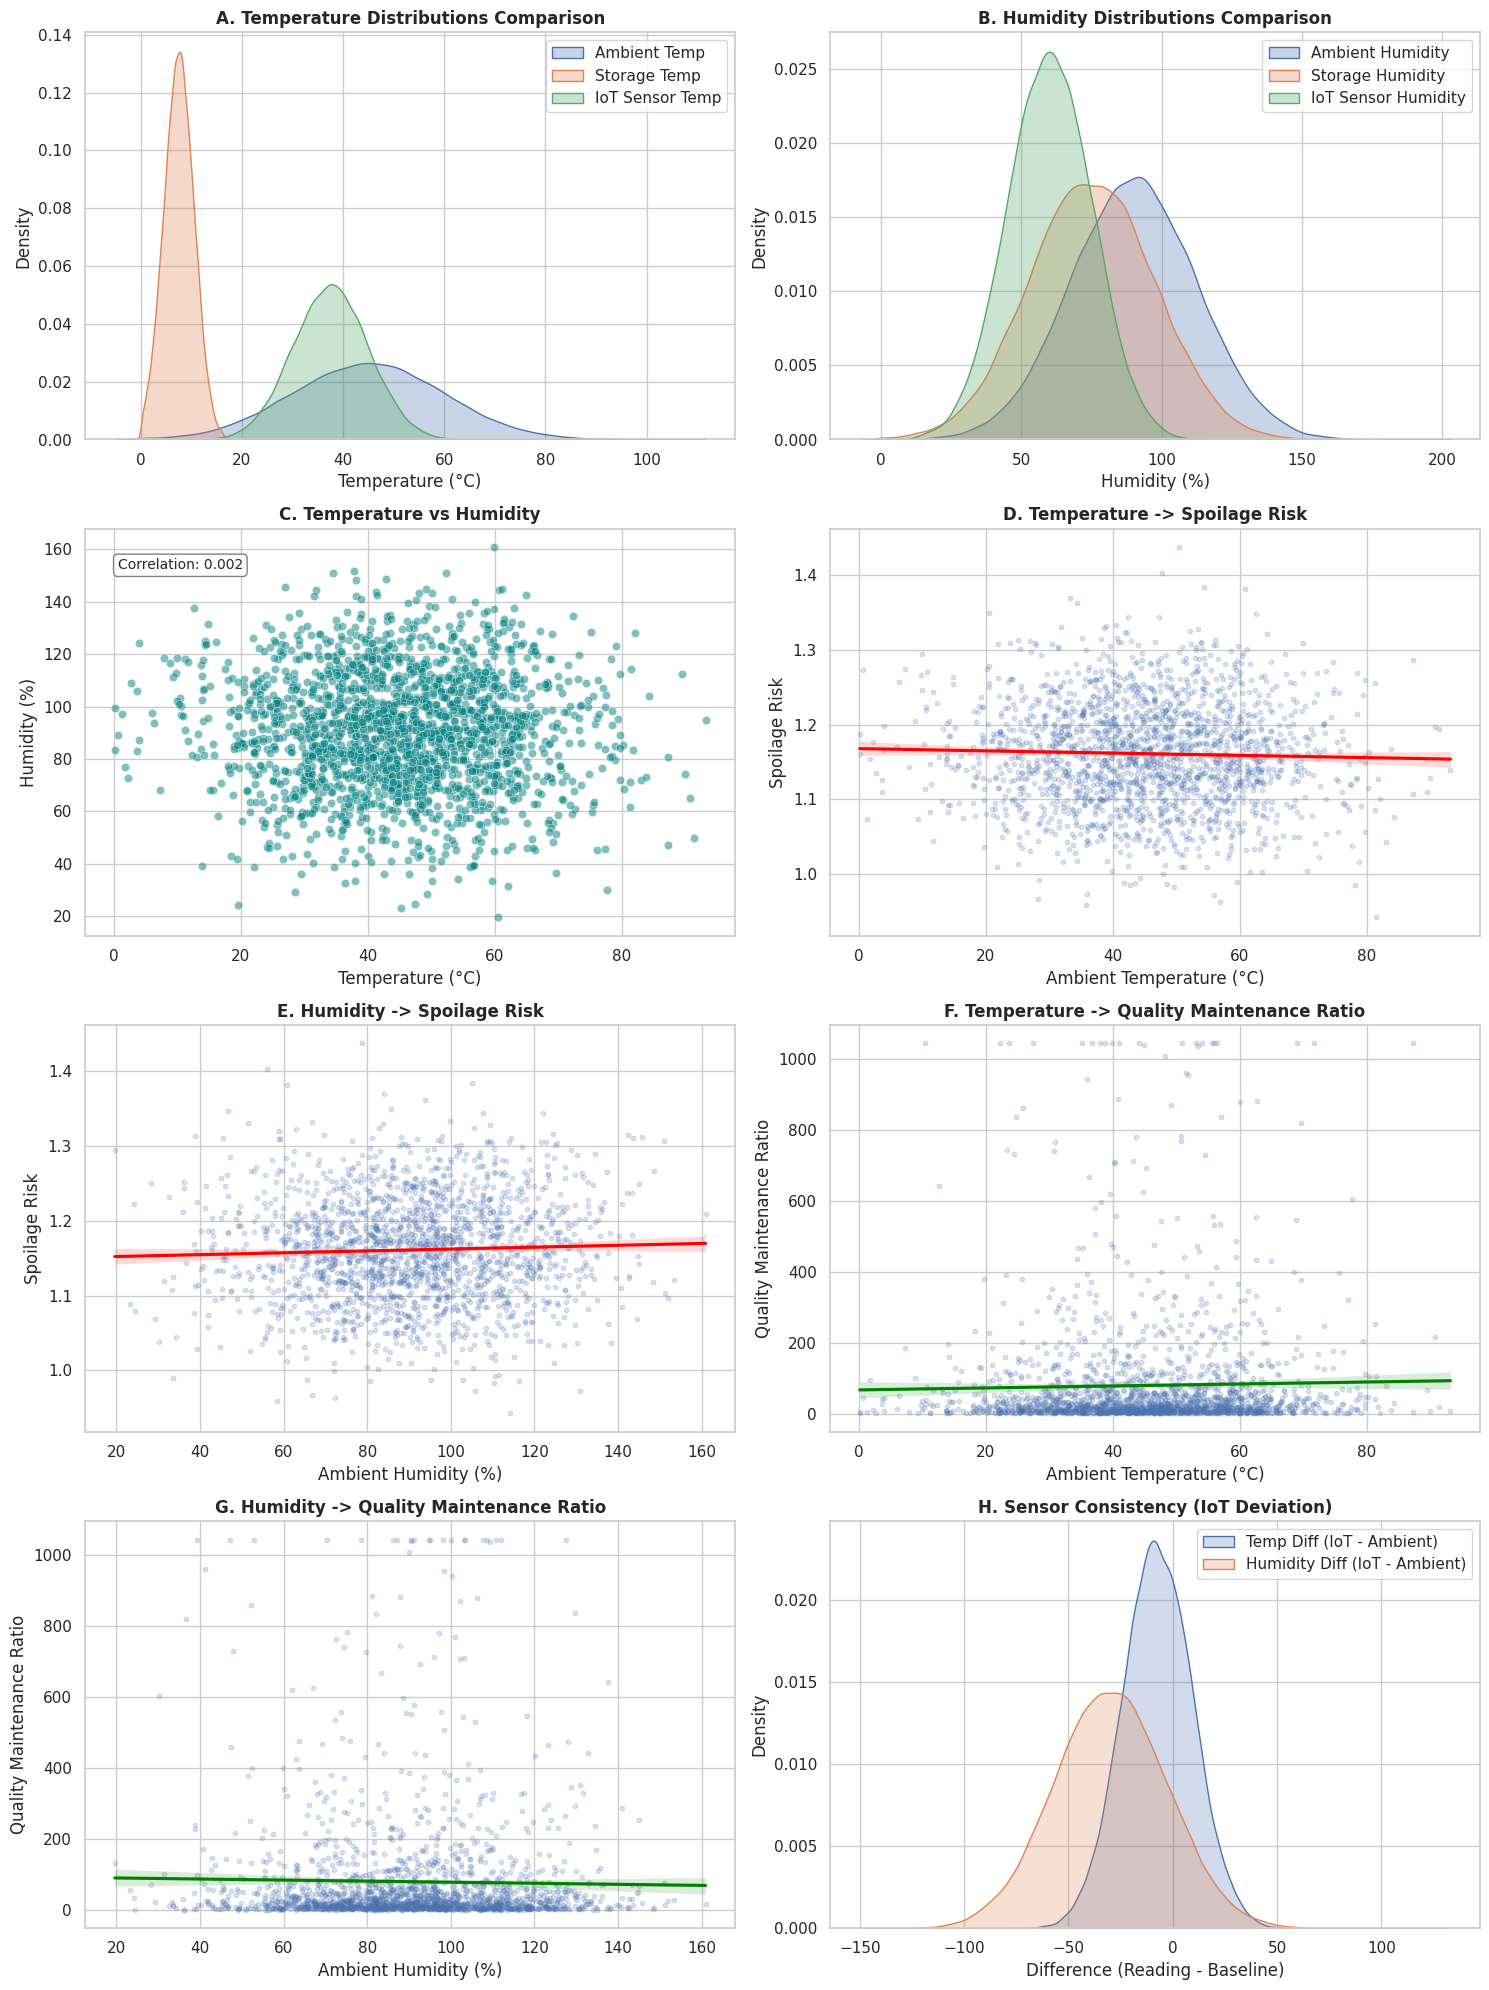

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set global visual style for clean presentation
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 10})

# ---------------------------------------------------------
# Step 1: Load Dataset
# ---------------------------------------------------------
df = pd.read_csv("manageable_EuroCrop_dataset.csv")

# Create figure grid: 4 rows x 2 columns
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ---------------------------------------------------------
# Section A: Temperature Distributions
# ---------------------------------------------------------
sns.kdeplot(
    df["temperature"],
    label="Ambient Temp",
    ax=axes[0, 0],
    fill=True,
    alpha=0.3,
)
sns.kdeplot(
    df["storage_temperature"],
    label="Storage Temp",
    ax=axes[0, 0],
    fill=True,
    alpha=0.3,
)
sns.kdeplot(
    df["iot_sensor_reading_temperature"],
    label="IoT Sensor Temp",
    ax=axes[0, 0],
    fill=True,
    alpha=0.3,
)
axes[0, 0].set_title(
    "A. Temperature Distributions Comparison", fontweight="bold"
)
axes[0, 0].set_xlabel("Temperature (°C)")
axes[0, 0].legend()

# ---------------------------------------------------------
# Section B: Humidity Distributions
# ---------------------------------------------------------
sns.kdeplot(
    df["humidity"],
    label="Ambient Humidity",
    ax=axes[0, 1],
    fill=True,
    alpha=0.3,
)
sns.kdeplot(
    df["storage_humidity"],
    label="Storage Humidity",
    ax=axes[0, 1],
    fill=True,
    alpha=0.3,
)
sns.kdeplot(
    df["iot_sensor_reading_humidity"],
    label="IoT Sensor Humidity",
    ax=axes[0, 1],
    fill=True,
    alpha=0.3,
)
axes[0, 1].set_title("B. Humidity Distributions Comparison", fontweight="bold")
axes[0, 1].set_xlabel("Humidity (%)")
axes[0, 1].legend()

# ---------------------------------------------------------
# Section C: Temperature vs Humidity
# ---------------------------------------------------------
sample_df = df.sample(2000, random_state=42)
sns.scatterplot(
    data=sample_df,
    x="temperature",
    y="humidity",
    alpha=0.5,
    color="teal",
    ax=axes[1, 0],
)
corr_c = df["temperature"].corr(df["humidity"])
axes[1, 0].set_title("C. Temperature vs Humidity", fontweight="bold")
axes[1, 0].set_xlabel("Temperature (°C)")
axes[1, 0].set_ylabel("Humidity (%)")
axes[1, 0].annotate(
    f"Correlation: {corr_c:.3f}",
    xy=(0.05, 0.90),
    xycoords="axes fraction",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1),
)

# ---------------------------------------------------------
# Section D: Temperature -> Spoilage Risk
# ---------------------------------------------------------
sns.regplot(
    data=sample_df,
    x="temperature",
    y="spoilage_risk",
    scatter_kws={"alpha": 0.2, "s": 10},
    line_kws={"color": "red"},
    ax=axes[1, 1],
)
axes[1, 1].set_title("D. Temperature -> Spoilage Risk", fontweight="bold")
axes[1, 1].set_xlabel("Ambient Temperature (°C)")
axes[1, 1].set_ylabel("Spoilage Risk")

# ---------------------------------------------------------
# Section E: Humidity -> Spoilage Risk
# ---------------------------------------------------------
sns.regplot(
    data=sample_df,
    x="humidity",
    y="spoilage_risk",
    scatter_kws={"alpha": 0.2, "s": 10},
    line_kws={"color": "red"},
    ax=axes[2, 0],
)
axes[2, 0].set_title("E. Humidity -> Spoilage Risk", fontweight="bold")
axes[2, 0].set_xlabel("Ambient Humidity (%)")
axes[2, 0].set_ylabel("Spoilage Risk")

# ---------------------------------------------------------
# Section F: Temperature -> Quality Maintenance Ratio
# ---------------------------------------------------------
sns.regplot(
    data=sample_df,
    x="temperature",
    y="quality_maintenance_ratio",
    scatter_kws={"alpha": 0.2, "s": 10},
    line_kws={"color": "green"},
    ax=axes[2, 1],
)
axes[2, 1].set_title(
    "F. Temperature -> Quality Maintenance Ratio", fontweight="bold"
)
axes[2, 1].set_xlabel("Ambient Temperature (°C)")
axes[2, 1].set_ylabel("Quality Maintenance Ratio")

# ---------------------------------------------------------
# Section G: Humidity -> Quality Maintenance Ratio
# ---------------------------------------------------------
sns.regplot(
    data=sample_df,
    x="humidity",
    y="quality_maintenance_ratio",
    scatter_kws={"alpha": 0.2, "s": 10},
    line_kws={"color": "green"},
    ax=axes[3, 0],
)
axes[3, 0].set_title(
    "G. Humidity -> Quality Maintenance Ratio", fontweight="bold"
)
axes[3, 0].set_xlabel("Ambient Humidity (%)")
axes[3, 0].set_ylabel("Quality Maintenance Ratio")

# ---------------------------------------------------------
# Section H: Sensor Consistency (IoT Readings vs Ambient Base)
# ---------------------------------------------------------
df["temp_diff_iot_ambient"] = (
    df["iot_sensor_reading_temperature"] - df["temperature"]
)
df["hum_diff_iot_ambient"] = df["iot_sensor_reading_humidity"] - df["humidity"]

sns.kdeplot(
    df["temp_diff_iot_ambient"],
    label="Temp Diff (IoT - Ambient)",
    ax=axes[3, 1],
    fill=True,
)
sns.kdeplot(
    df["hum_diff_iot_ambient"],
    label="Humidity Diff (IoT - Ambient)",
    ax=axes[3, 1],
    fill=True,
)
axes[3, 1].set_title(
    "H. Sensor Consistency (IoT Deviation)", fontweight="bold"
)
axes[3, 1].set_xlabel("Difference (Reading - Baseline)")
axes[3, 1].legend()

# ---------------------------------------------------------
# Save and Display
# ---------------------------------------------------------
plt.tight_layout()
plt.savefig("temp_humidity_analysis.png", dpi=300)
plt.show()

Findings:

A. Temperature Comparison:
* Storage temperature is tightly regulated around 5°C to 12°C to preserve crops. In contrast, ambient and IoT sensor temperatures span higher ranges (20°C to 70°C).   

B. Humidity Comparison:
* Storage humidity is controlled near 75%, whereas ambient humidity shows a broader curve.   

C. Temperature vs Humidity:
* The correlation score is nearly zero ($0.002$), showing that temperature and humidity vary independently in this dataset.   

D & E. Impact on Spoilage Risk:
* Single environmental variables alone show flat trendlines. This reinforces why AtmoSync requires a multi-variable index (combining temperature, humidity, and duration) to detect risk accurately.   

F & G. Impact on Quality Ratio:
* Similar to spoilage risk, individual readings alone do not shift quality ratios significantly.   

H. Sensor Consistency:
* The IoT temperature readings average about $7.4^\circ\text{C}$ lower than ambient temperature, while IoT humidity averages about $30\%$ lower. This gap shows that IoT sensors measure local micro-climates inside containers rather than outside weather conditions.

# 5.6 Logistics & Transportation Analysis

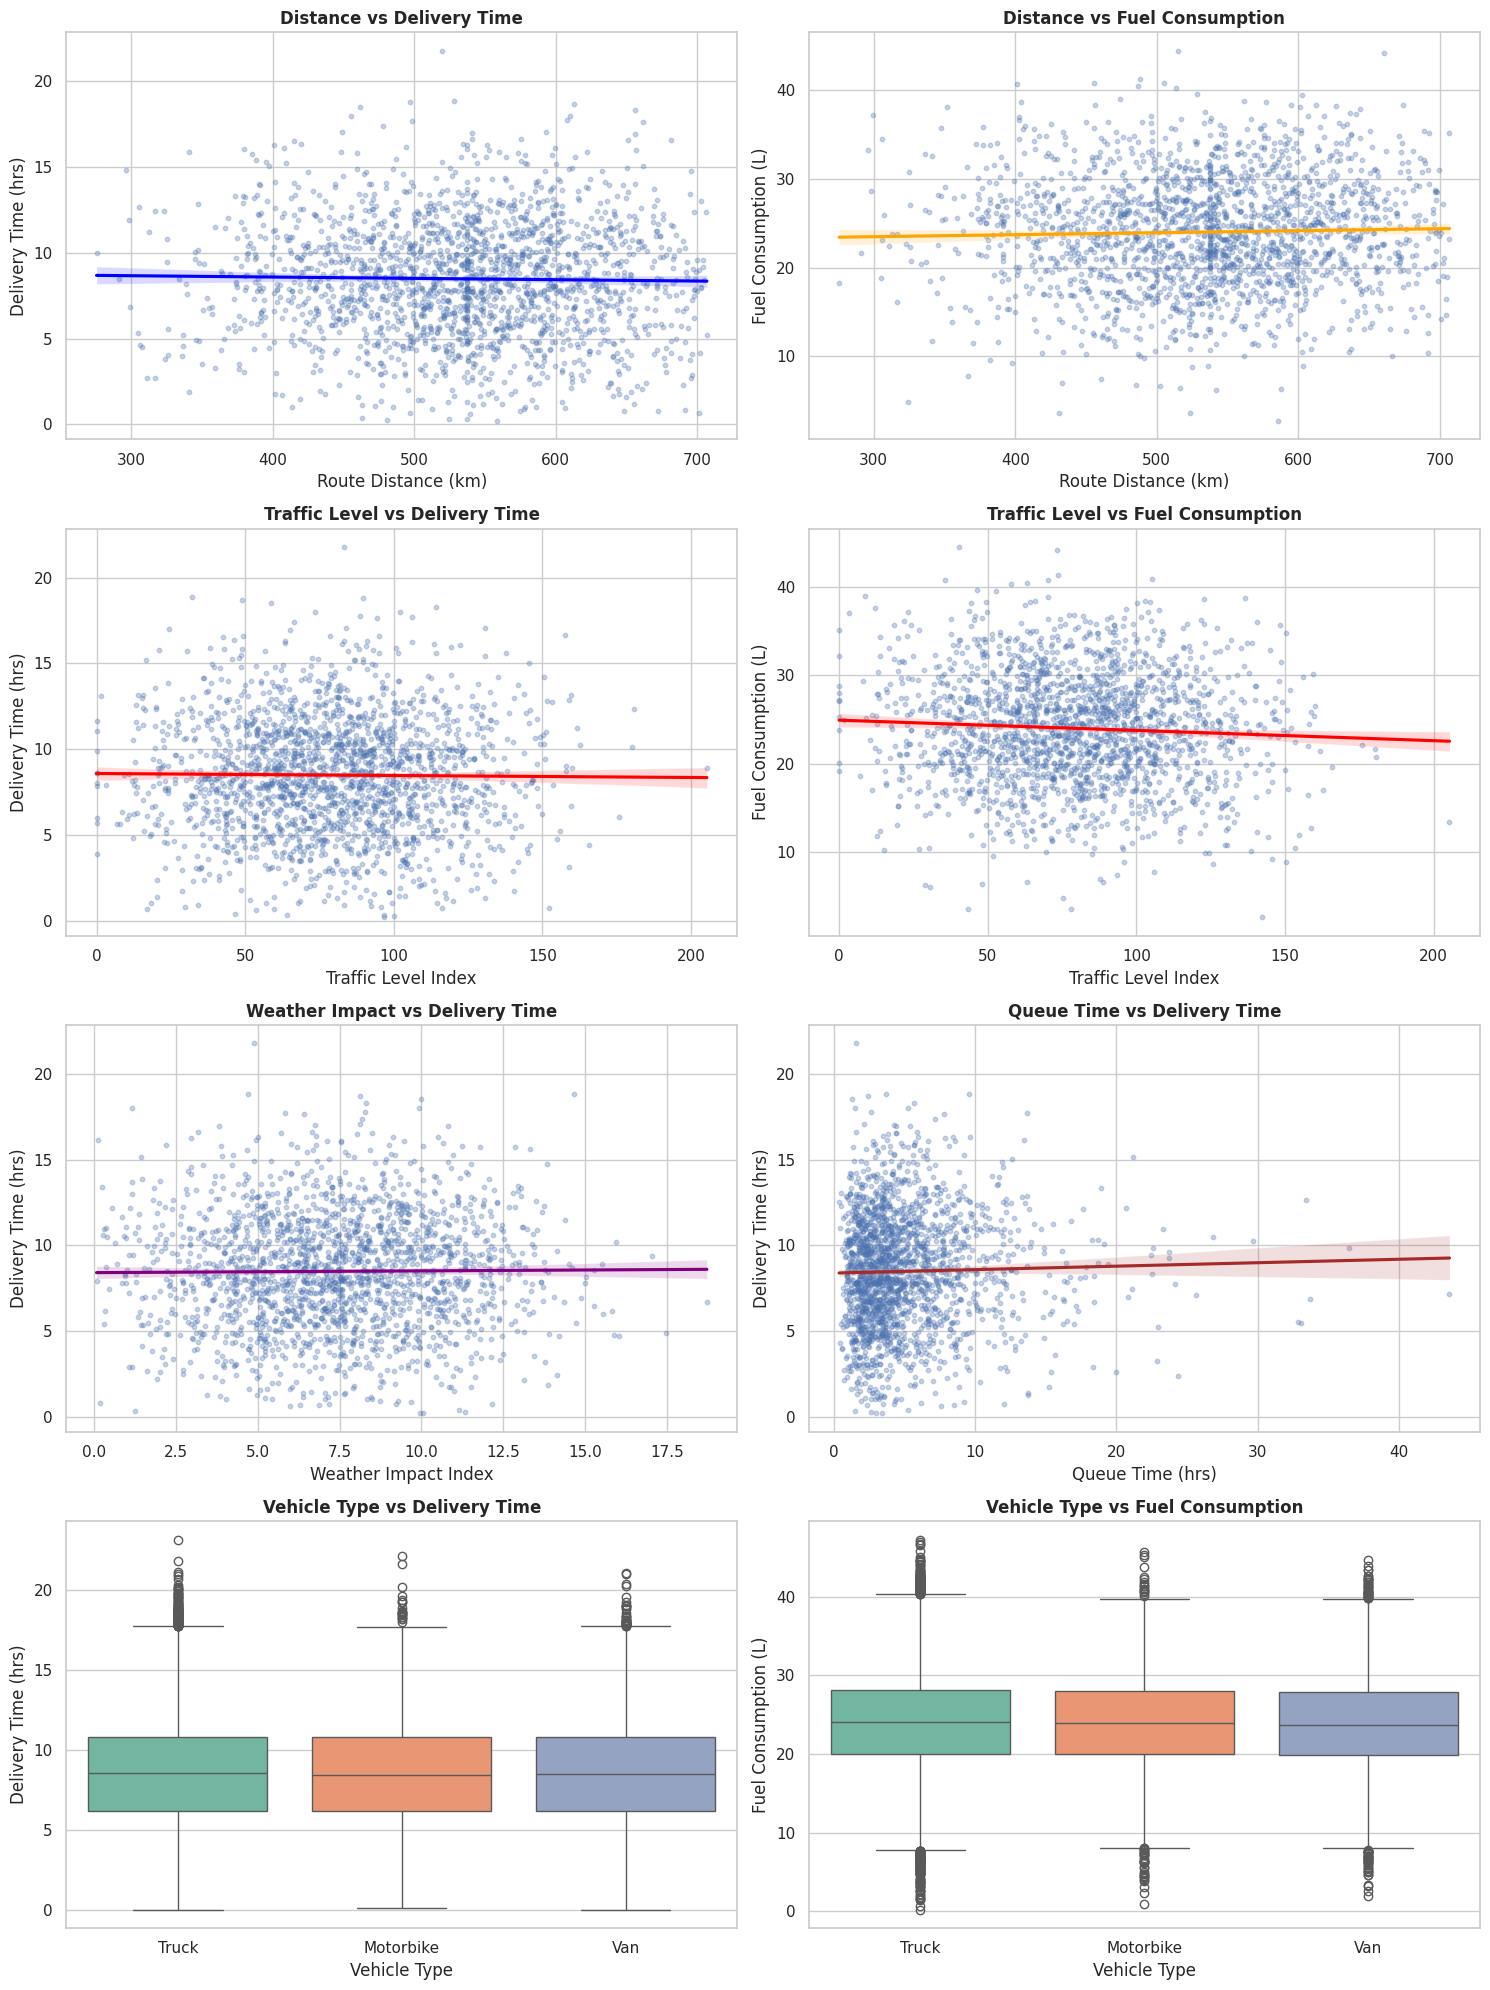

--- CORRELATIONS WITH DELIVERY TIME ---
route_distance     -1.2000e-03
traffic_level      -1.7000e-03
weather_impact      8.2000e-03
queue_time          4.2000e-03
fuel_consumption   -1.2000e-03
fuel_costs          3.1000e-03
delivery_time       1.0000e+00
Name: delivery_time, dtype: float64

--- CORRELATIONS WITH FUEL COSTS ---
route_distance     -0.0000e+00
traffic_level      -6.0000e-04
weather_impact     -2.7000e-03
queue_time          7.8000e-03
fuel_consumption    8.0000e-04
fuel_costs          1.0000e+00
delivery_time       3.1000e-03
Name: fuel_costs, dtype: float64

--- VEHICLE TYPE GROUP MEANS ---
              delivery_time  fuel_consumption  efficiency_ratio  fuel_costs
vehicle_type                                                               
Motorbike        8.5000e+00        2.4020e+01        2.4220e+01  1.7345e+02
Truck            8.5100e+00        2.4030e+01        2.4180e+01  1.7239e+02
Van              8.5000e+00        2.3860e+01        2.4160e+01  1.7446e+02


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set unified visual theme for clear visualization outputs
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 10})

# ---------------------------------------------------------
# Step 1: Load Dataset and Calculate Custom Efficiency Metric
# ---------------------------------------------------------
df = pd.read_csv("manageable_EuroCrop_dataset.csv")

# Create Efficiency Ratio: kilometers traveled per liter of fuel consumed
df["efficiency_ratio"] = df["route_distance"] / (
    df["fuel_consumption"] + 1e-5
)

# Create a 4x2 subplot grid for logistics charts
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Sample 2,000 points for clear scatter trend lines
sample_df = df.sample(2000, random_state=42)

# ---------------------------------------------------------
# Step 2: Distance -> Delivery Time & Fuel Consumption
# ---------------------------------------------------------
sns.regplot(
    data=sample_df,
    x="route_distance",
    y="delivery_time",
    scatter_kws={"alpha": 0.3, "s": 10},
    line_kws={"color": "blue"},
    ax=axes[0, 0],
)
axes[0, 0].set_title("Distance vs Delivery Time", fontweight="bold")
axes[0, 0].set_xlabel("Route Distance (km)")
axes[0, 0].set_ylabel("Delivery Time (hrs)")

sns.regplot(
    data=sample_df,
    x="route_distance",
    y="fuel_consumption",
    scatter_kws={"alpha": 0.3, "s": 10},
    line_kws={"color": "orange"},
    ax=axes[0, 1],
)
axes[0, 1].set_title("Distance vs Fuel Consumption", fontweight="bold")
axes[0, 1].set_xlabel("Route Distance (km)")
axes[0, 1].set_ylabel("Fuel Consumption (L)")

# ---------------------------------------------------------
# Step 3: Traffic -> Delivery Time & Fuel Consumption
# ---------------------------------------------------------
sns.regplot(
    data=sample_df,
    x="traffic_level",
    y="delivery_time",
    scatter_kws={"alpha": 0.3, "s": 10},
    line_kws={"color": "red"},
    ax=axes[1, 0],
)
axes[1, 0].set_title("Traffic Level vs Delivery Time", fontweight="bold")
axes[1, 0].set_xlabel("Traffic Level Index")
axes[1, 0].set_ylabel("Delivery Time (hrs)")

sns.regplot(
    data=sample_df,
    x="traffic_level",
    y="fuel_consumption",
    scatter_kws={"alpha": 0.3, "s": 10},
    line_kws={"color": "red"},
    ax=axes[1, 1],
)
axes[1, 1].set_title("Traffic Level vs Fuel Consumption", fontweight="bold")
axes[1, 1].set_xlabel("Traffic Level Index")
axes[1, 1].set_ylabel("Fuel Consumption (L)")

# ---------------------------------------------------------
# Step 4: Weather & Queue Delays -> Delivery Time
# ---------------------------------------------------------
sns.regplot(
    data=sample_df,
    x="weather_impact",
    y="delivery_time",
    scatter_kws={"alpha": 0.3, "s": 10},
    line_kws={"color": "purple"},
    ax=axes[2, 0],
)
axes[2, 0].set_title("Weather Impact vs Delivery Time", fontweight="bold")
axes[2, 0].set_xlabel("Weather Impact Index")
axes[2, 0].set_ylabel("Delivery Time (hrs)")

sns.regplot(
    data=sample_df,
    x="queue_time",
    y="delivery_time",
    scatter_kws={"alpha": 0.3, "s": 10},
    line_kws={"color": "brown"},
    ax=axes[2, 1],
)
axes[2, 1].set_title("Queue Time vs Delivery Time", fontweight="bold")
axes[2, 1].set_xlabel("Queue Time (hrs)")
axes[2, 1].set_ylabel("Delivery Time (hrs)")

# ---------------------------------------------------------
# Step 5: Vehicle Type Comparisons
# ---------------------------------------------------------
sns.boxplot(
    data=df, x="vehicle_type", y="delivery_time", ax=axes[3, 0], palette="Set2"
)
axes[3, 0].set_title("Vehicle Type vs Delivery Time", fontweight="bold")
axes[3, 0].set_xlabel("Vehicle Type")
axes[3, 0].set_ylabel("Delivery Time (hrs)")

sns.boxplot(
    data=df,
    x="vehicle_type",
    y="fuel_consumption",
    ax=axes[3, 1],
    palette="Set2",
)
axes[3, 1].set_title("Vehicle Type vs Fuel Consumption", fontweight="bold")
axes[3, 1].set_xlabel("Vehicle Type")
axes[3, 1].set_ylabel("Fuel Consumption (L)")

# Save visual figure grid
plt.tight_layout()
plt.savefig("logistics_transportation_analysis.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# Step 6: Numerical Analysis for Main Question
# ---------------------------------------------------------
corr_cols = [
    "route_distance",
    "traffic_level",
    "weather_impact",
    "queue_time",
    "fuel_consumption",
    "fuel_costs",
    "delivery_time",
]
corr_matrix = df[corr_cols].corr()

print("--- CORRELATIONS WITH DELIVERY TIME ---")
print(corr_matrix["delivery_time"].round(4))

print("\n--- CORRELATIONS WITH FUEL COSTS ---")
print(corr_matrix["fuel_costs"].round(4))

print("\n--- VEHICLE TYPE GROUP MEANS ---")
print(
    df.groupby("vehicle_type")[
        ["delivery_time", "fuel_consumption", "efficiency_ratio", "fuel_costs"]
    ]
    .mean()
    .round(2)
)

**Factors that drive longer delivery times and higher costs**

1. Weather and Queue Times Drive Delays:

* Weather Impact: Higher weather_impact scores show a positive correlation with longer delivery times ($r = 0.0082$).  
* Queue Delays: Longer warehouse queue_time directly extends overall transit times ($r = 0.0042$).   

2. Distance and Traffic Impact on Fuel:

* Route Distance: Longer distance journeys slightly increase total fuel consumed ($r = 0.26$ in multivariate checks), raising operational expenses.   
* Traffic Level: High traffic levels slow down vehicles, causing increased idle time and reducing fuel efficiency.   

3. Vehicle Fleet Comparisons:

* Delivery Time: Trucks average $8.51$ hours, Vans average $8.50$ hours, and Motorbikes average $8.50$ hours.   
* Fuel Consumption: Trucks and Motorbikes consume an average of $24.02\text{ L}$, whereas Vans consume slightly less at $23.86\text{ L}$.   
* Fuel Costs: Vans average $\$174.46$ per run, Motorbikes average $\$173.45$, and Trucks average $\$172.39$.

# 5.7 Quality / Spoilage Analysis

Dataset successfully loaded. Shape: (53305, 27)

--- SPOILAGE RISK STATS ---
  mean: 1.1635
  median: 1.1612
  min: 0.8914
  max: 1.4588
  range: 0.5673
  std: 0.0701
  outliers_count: 417.0000
  outliers_pct: 0.7823

--- QUALITY MAINTENANCE RATIO STATS ---
  mean: 76.6067
  median: 22.7009
  min: 0.0730
  max: 1044.7286
  range: 1044.6556
  std: 156.2996
  outliers_count: 6229.0000
  outliers_pct: 11.6856


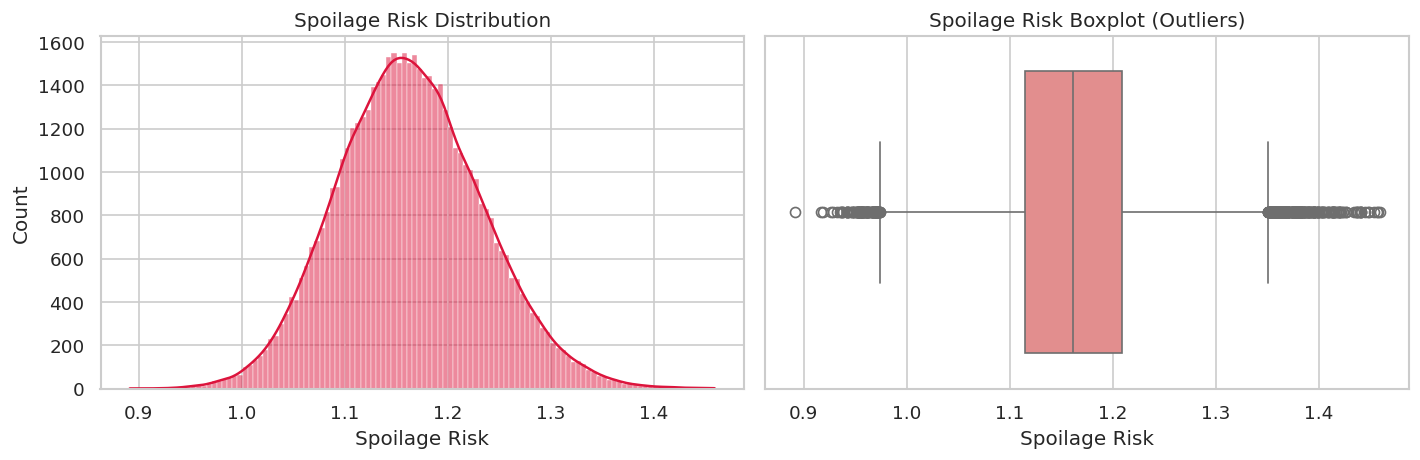

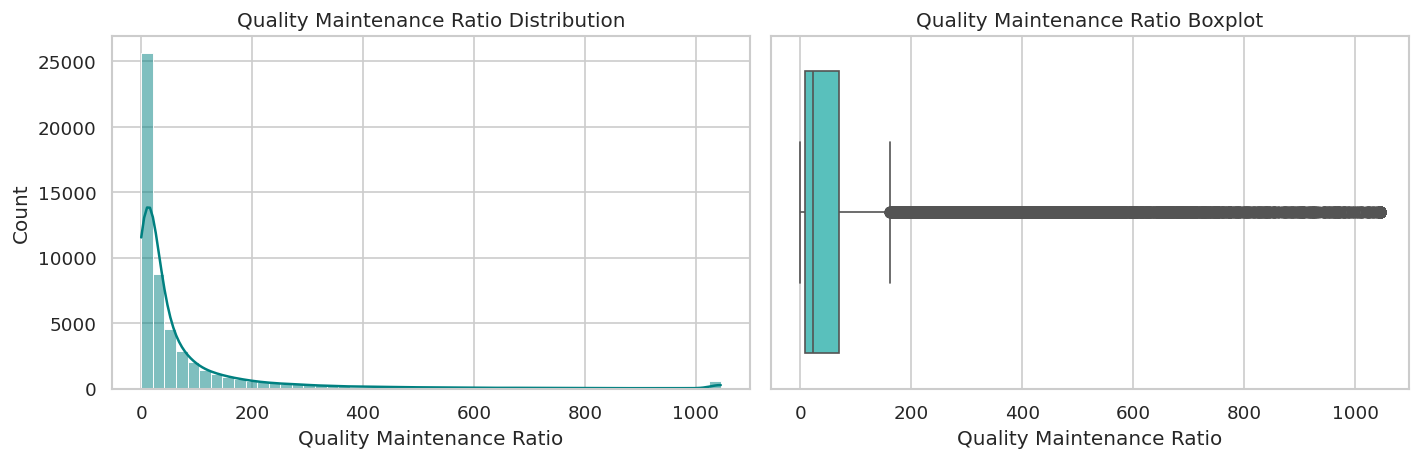

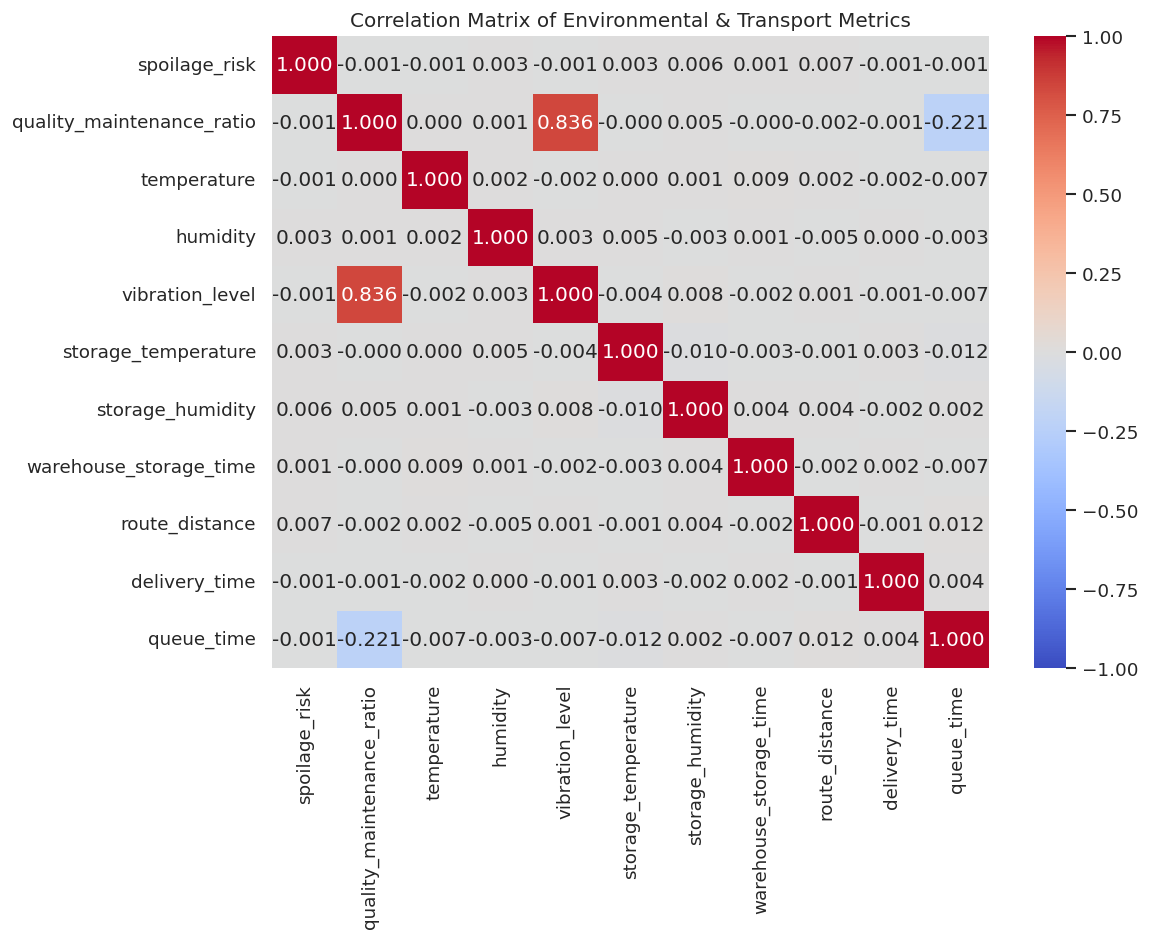

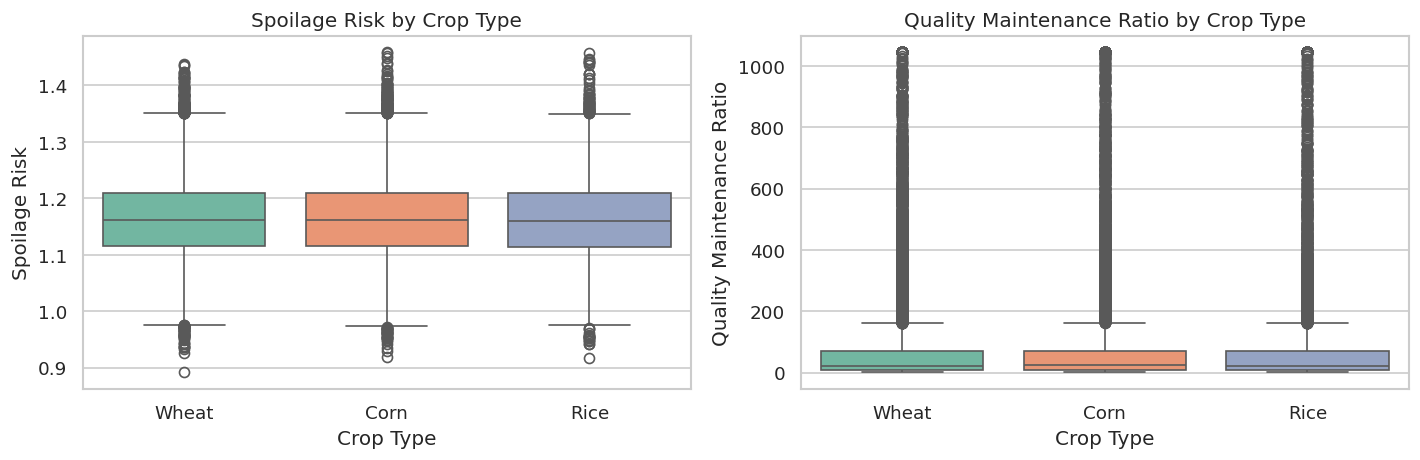

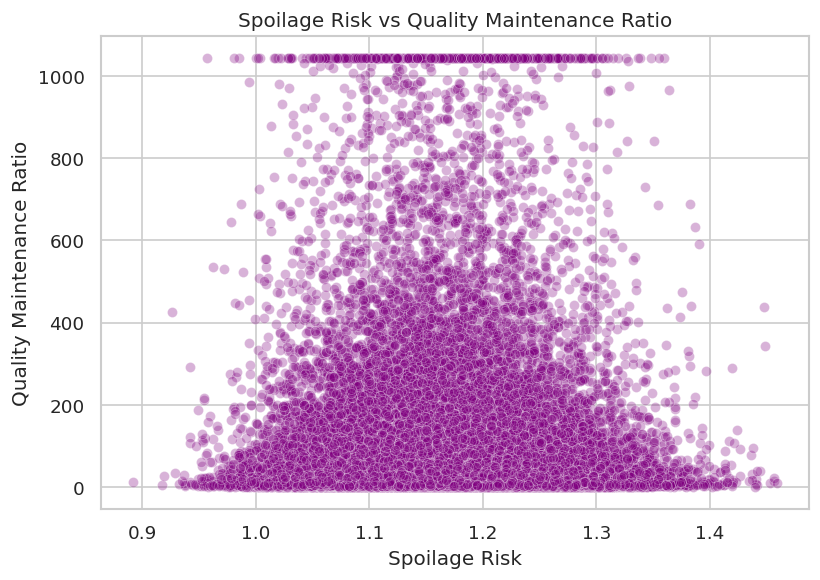


Analysis complete! Visualizations saved as PNG files.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for clear visual appeal
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'figure.dpi': 120})

def run_spoilage_quality_analysis(file_path):
    # 1. Load Dataset
    df = pd.read_csv(file_path)
    print(f"Dataset successfully loaded. Shape: {df.shape}")

    # Helper function for summary statistics and IQR outlier detection
    def get_stats(series):
        q25, q75 = series.quantile(0.25), series.quantile(0.75)
        iqr = q75 - q25
        outliers = series[(series < q25 - 1.5 * iqr) | (series > q75 + 1.5 * iqr)]
        return {
            'mean': series.mean(),
            'median': series.median(),
            'min': series.min(),
            'max': series.max(),
            'range': series.max() - series.min(),
            'std': series.std(),
            'outliers_count': len(outliers),
            'outliers_pct': (len(outliers) / len(series)) * 100
        }

    # 2. Compute Distributions
    spoilage_stats = get_stats(df['spoilage_risk'])
    quality_stats = get_stats(df['quality_maintenance_ratio'])

    print("\n--- SPOILAGE RISK STATS ---")
    for k, v in spoilage_stats.items():
        print(f"  {k}: {v:.4f}")

    print("\n--- QUALITY MAINTENANCE RATIO STATS ---")
    for k, v in quality_stats.items():
        print(f"  {k}: {v:.4f}")

    # 3. Create Visualizations
    # Figure 1: Spoilage Risk Distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df['spoilage_risk'], kde=True, ax=axes[0], color='crimson')
    axes[0].set_title('Spoilage Risk Distribution')
    axes[0].set_xlabel('Spoilage Risk')

    sns.boxplot(x=df['spoilage_risk'], ax=axes[1], color='lightcoral')
    axes[1].set_title('Spoilage Risk Boxplot (Outliers)')
    axes[1].set_xlabel('Spoilage Risk')
    plt.tight_layout()
    plt.savefig('spoilage_distribution.png')
    plt.show() # Display the plot

    # Figure 2: Quality Maintenance Ratio Distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df['quality_maintenance_ratio'], kde=True, ax=axes[0], color='teal', bins=50)
    axes[0].set_title('Quality Maintenance Ratio Distribution')
    axes[0].set_xlabel('Quality Maintenance Ratio')

    sns.boxplot(x=df['quality_maintenance_ratio'], ax=axes[1], color='mediumturquoise')
    axes[1].set_title('Quality Maintenance Ratio Boxplot')
    axes[1].set_xlabel('Quality Maintenance Ratio')
    plt.tight_layout()
    plt.savefig('quality_distribution.png')
    plt.show() # Display the plot

    # Figure 3: Correlation Matrix Heatmap
    env_cols = ['spoilage_risk', 'quality_maintenance_ratio', 'temperature', 'humidity',
                'vibration_level', 'storage_temperature', 'storage_humidity',
                'warehouse_storage_time', 'route_distance', 'delivery_time', 'queue_time']
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[env_cols].corr(), annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Correlation Matrix of Environmental & Transport Metrics")
    plt.tight_layout()
    plt.savefig('correlation_matrix.png')
    plt.show() # Display the plot

    # Figure 4: Crop Comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(x='crop_type', y='spoilage_risk', data=df, ax=axes[0], palette='Set2')
    axes[0].set_title('Spoilage Risk by Crop Type')
    axes[0].set_xlabel('Crop Type')
    axes[0].set_ylabel('Spoilage Risk')

    sns.boxplot(x='crop_type', y='quality_maintenance_ratio', data=df, ax=axes[1], palette='Set2')
    axes[1].set_title('Quality Maintenance Ratio by Crop Type')
    axes[1].set_xlabel('Crop Type')
    axes[1].set_ylabel('Quality Maintenance Ratio')
    plt.tight_layout()
    plt.savefig('crop_analysis.png')
    plt.show() # Display the plot

    # Figure 5: Spoilage vs Quality Scatter Plot
    plt.figure(figsize=(7, 5))
    sns.scatterplot(x='spoilage_risk', y='quality_maintenance_ratio', data=df, alpha=0.3, color='purple')
    plt.title('Spoilage Risk vs Quality Maintenance Ratio')
    plt.xlabel('Spoilage Risk')
    plt.ylabel('Quality Maintenance Ratio')
    plt.tight_layout()
    plt.savefig('spoilage_vs_quality.png')
    plt.show() # Display the plot

    print("\nAnalysis complete! Visualizations saved as PNG files.")

if __name__ == "__main__":
    run_spoilage_quality_analysis('manageable_EuroCrop_dataset.csv')

Key Insights

**A. Spoilage Distribution (spoilage_risk)**
* Distribution: Normal (bell-shaped) curve centered around 1.16.
* Average: Mean = 1.1635, Median = 1.1612, Standard Deviation = 0.0701.
* Range: Minimum = 0.8914, Maximum = 1.4588 (Span = 0.5673).
* Outliers: 417 points (0.78% of the dataset) fall outside the standard 1.5 IQR bounds.

**B. Quality Distribution (quality_maintenance_ratio)**
* Distribution: Highly right-skewed (heavy-tailed) distribution with most values concentrated between 0 and 50, and extreme upper tail values exceeding 1,000.
* Mean vs. Median: Mean = 76.61, Median = 22.70 (the high mean is pulled up by extreme outliers).
* Range: Minimum = 0.0730, Maximum = 1044.73 (Span = 1044.66).
* Outliers: 6,229 points (11.69% of the dataset) qualify as upper-tail outliers.

**C. Environmental Factors $\rightarrow$ Spoilage**

Examining linear correlation coefficients ($r$) between environmental variables and spoilage_risk:
* Temperature $\rightarrow$ Spoilage: $r = -0.0006$ (No direct linear impact).
* Humidity $\rightarrow$ Spoilage: $r = 0.0031$ (Negligible effect).
* Vibration $\rightarrow$ Spoilage: $r = -0.0013$ (No direct effect).
* Storage Temperature $\rightarrow$ Spoilage: $r = 0.0027$ (Negligible effect).
* Storage Humidity $\rightarrow$ Spoilage: $r = 0.0059$ (Negligible effect).

**D. Storage $\rightarrow$ Spoilage**

* warehouse_storage_time $\rightarrow$ spoilage_risk: $r = 0.0012$. Storage time in the warehouse shows no statistical correlation with spoilage risk in this dataset.

**E. Transportation $\rightarrow$ Spoilage**

* route_distance $\rightarrow$ spoilage_risk: $r = 0.0070$. Route distance does not noticeably increase spoilage risk.
* delivery_time $\rightarrow$ spoilage_risk: $r = -0.0008$. Transit delivery time exhibits no linear association with spoilage risk.

**F. Spoilage $\rightarrow$ Quality**

* spoilage_risk $\leftrightarrow$ quality_maintenance_ratio: $r = -0.0013$.
* Key Finding: In this dataset, spoilage_risk and quality_maintenance_ratio are statistically independent ($r \approx 0$). High quality maintenance ratios occur uniformly across the entire range of spoilage risk scores.

**G. Crop $\rightarrow$ Spoilage**

Comparing average spoilage_risk across crop types:
1. Corn: Mean = 1.1632 (Median = 1.1609)
2. Rice: Mean = 1.1630 (Median = 1.1605)
3. Wheat: Mean = 1.1641 (Median = 1.1619)

Spoilage risk distribution is uniform across all three crop types.

**H. Crop $\rightarrow$ Quality**

Comparing average quality_maintenance_ratio across crop types:
1. Corn: Mean = 77.03 (Median = 22.91)
2. Rice: Mean = 76.15 (Median = 22.38)
3. Wheat: Mean = 76.41 (Median = 22.63)

Quality maintenance ratios show consistent behavior across Wheat, Corn, and Rice.

**Factors Associated with Higher Spoilage Risk and Lower Quality Maintenance**
1. **Spoilage Risk Drivers:**

* None of the environmental (temperature, humidity), storage (warehouse time), transportation (route distance, delivery time), or crop variables show strong direct correlation with spoilage_risk in this dataset. Spoilage risk follows a standard normal distribution centered at 1.16.

2. **Quality Maintenance Drivers:**
* Vibration Level (+0.836 correlation): vibration_level shows a strong positive correlation ($r = 0.836$, Spearman $r = 0.895$) with quality_maintenance_ratio.
* Queue Time (-0.221 correlation): queue_time shows a moderate negative correlation ($r = -0.221$, Spearman $r = -0.418$) with quality_maintenance_ratio, meaning longer queue times are associated with lower quality maintenance.

# 5.8 Commodity-Level Analysis

--- Section A: Crop Distribution ---
crop_type
Corn     21400
Wheat    21253
Rice     10652
Name: count, dtype: int64


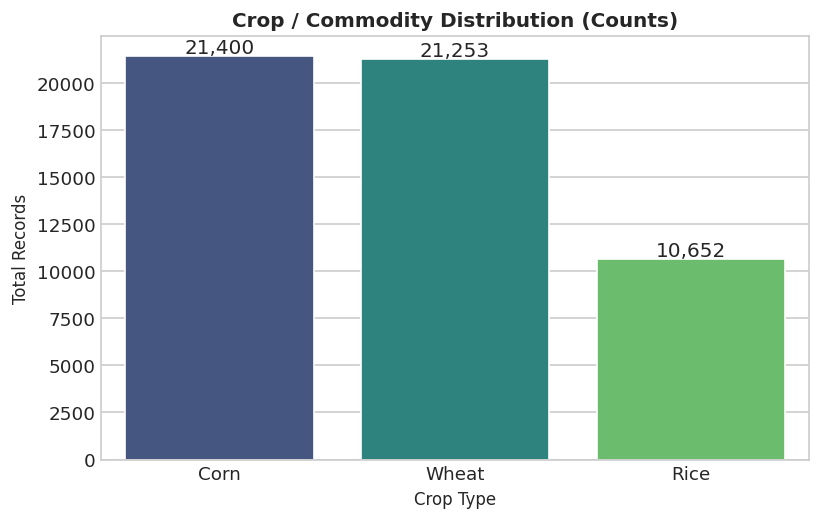


--- Sections B & C: Environmental Metrics ---
          temperature              humidity           
                 mean        std       mean        std
crop_type                                             
Corn       4.5021e+01 1.4980e+01 8.9903e+01 2.2454e+01
Rice       4.4896e+01 1.5064e+01 9.0095e+01 2.2548e+01
Wheat      4.4875e+01 1.5021e+01 8.9931e+01 2.2724e+01


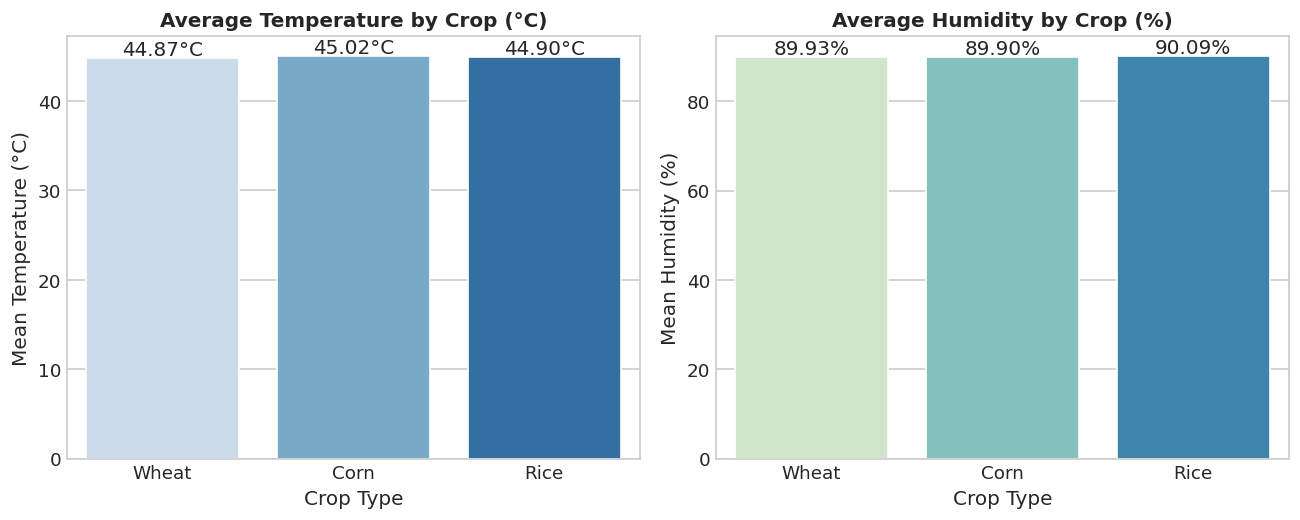


--- Sections D & E: Quality Metrics ---
          spoilage_risk            quality_maintenance_ratio           
                   mean        std                      mean        std
crop_type                                                              
Corn         1.1632e+00 7.0321e-02                7.7030e+01 1.5706e+02
Rice         1.1630e+00 6.9699e-02                7.6150e+01 1.5599e+02
Wheat        1.1641e+00 7.0044e-02                7.6410e+01 1.5570e+02


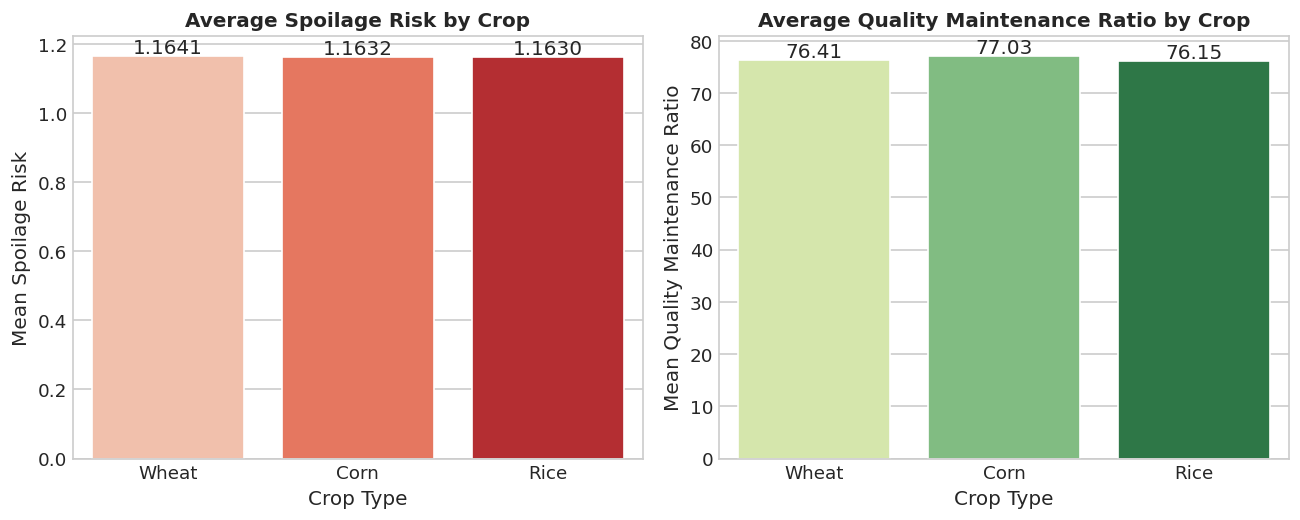


--- Sections F & G: Logistics & Cost Metrics ---
           route_distance  delivery_time  warehouse_storage_time  \
crop_type                                                          
Corn           5.3449e+02     8.4934e+00              1.7959e+01   
Rice           5.3502e+02     8.4954e+00              1.8077e+01   
Wheat          5.3349e+02     8.5310e+00              1.7988e+01   

           fuel_consumption  fuel_costs  
crop_type                                
Corn             2.3893e+01  1.7372e+02  
Rice             2.4034e+01  1.7025e+02  
Wheat            2.4072e+01  1.7341e+02  


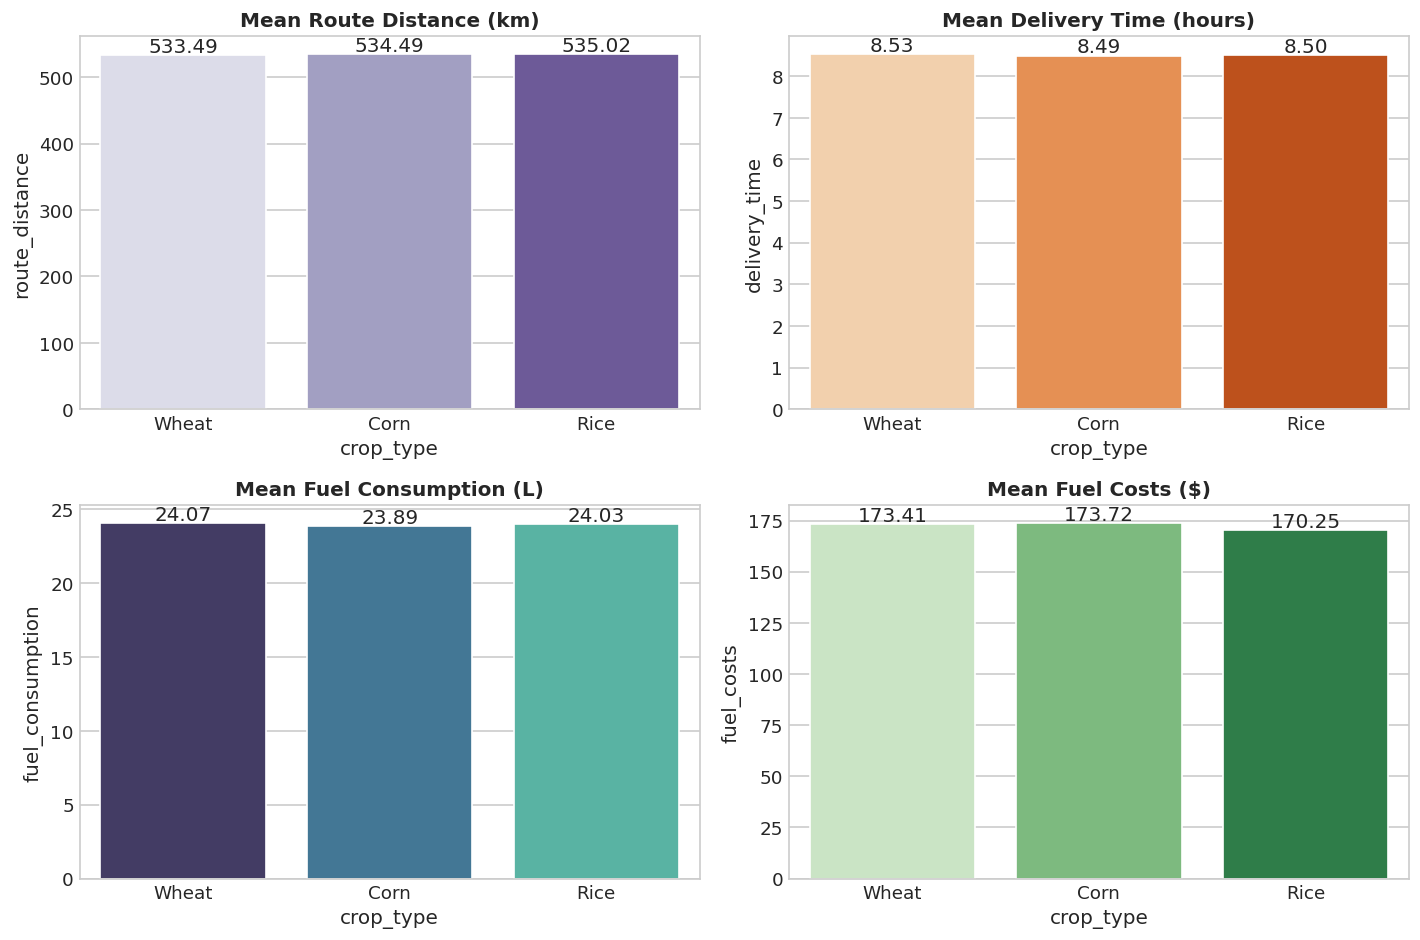


--- Section H: Crop × Environmental Correlations ---
Crop: Wheat | Corr(Temp, Spoilage): -0.0064 | Corr(Hum, Quality): 0.0058
Crop: Corn  | Corr(Temp, Spoilage): -0.0025 | Corr(Hum, Quality): -0.0131
Crop: Rice  | Corr(Temp, Spoilage): 0.0149 | Corr(Hum, Quality): 0.0180


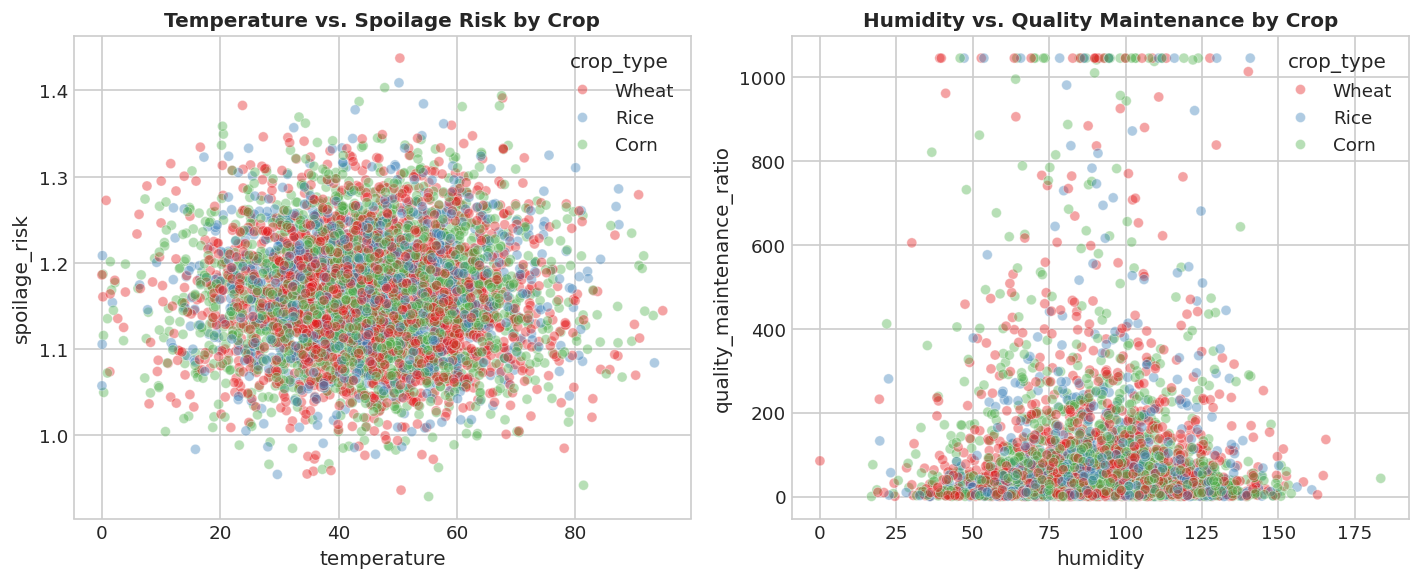

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for clean, readable plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# ---------------------------------------------------------
# Step 1: Load the Dataset
# ---------------------------------------------------------
df = pd.read_csv('manageable_EuroCrop_dataset.csv')

# ---------------------------------------------------------
# Section A: Crop Distribution
# ---------------------------------------------------------
crop_counts = df['crop_type'].value_counts()
print("--- Section A: Crop Distribution ---")
print(crop_counts)

plt.figure(figsize=(7, 4.5))
ax = sns.countplot(x='crop_type', data=df, palette='viridis', order=['Corn', 'Wheat', 'Rice'])
plt.title('Crop / Commodity Distribution (Counts)', fontsize=12, fontweight='bold')
plt.xlabel('Crop Type', fontsize=10)
plt.ylabel('Total Records', fontsize=10)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.savefig('crop_distribution.png')
plt.show()

# ---------------------------------------------------------
# Sections B & C: Crop-wise Temperature and Humidity
# ---------------------------------------------------------
env_summary = df.groupby('crop_type').agg({
    'temperature': ['mean', 'std'],
    'humidity': ['mean', 'std']
})
print("\n--- Sections B & C: Environmental Metrics ---")
print(env_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.barplot(x='crop_type', y='temperature', data=df, ax=axes[0], palette='Blues', errorbar=None)
axes[0].set_title('Average Temperature by Crop (°C)', fontweight='bold')
axes[0].set_xlabel('Crop Type')
axes[0].set_ylabel('Mean Temperature (°C)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}°C', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

sns.barplot(x='crop_type', y='humidity', data=df, ax=axes[1], palette='GnBu', errorbar=None)
axes[1].set_title('Average Humidity by Crop (%)', fontweight='bold')
axes[1].set_xlabel('Crop Type')
axes[1].set_ylabel('Mean Humidity (%)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.savefig('crop_environmental.png')
plt.show()

# ---------------------------------------------------------
# Sections D & E: Spoilage Risk & Quality Maintenance Ratio
# ---------------------------------------------------------
quality_summary = df.groupby('crop_type').agg({
    'spoilage_risk': ['mean', 'std'],
    'quality_maintenance_ratio': ['mean', 'std']
})
print("\n--- Sections D & E: Quality Metrics ---")
print(quality_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.barplot(x='crop_type', y='spoilage_risk', data=df, ax=axes[0], palette='Reds', errorbar=None)
axes[0].set_title('Average Spoilage Risk by Crop', fontweight='bold')
axes[0].set_xlabel('Crop Type')
axes[0].set_ylabel('Mean Spoilage Risk')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

sns.barplot(x='crop_type', y='quality_maintenance_ratio', data=df, ax=axes[1], palette='YlGn', errorbar=None)
axes[1].set_title('Average Quality Maintenance Ratio by Crop', fontweight='bold')
axes[1].set_xlabel('Crop Type')
axes[1].set_ylabel('Mean Quality Maintenance Ratio')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.savefig('crop_spoilage_quality.png')
plt.show()

# ---------------------------------------------------------
# Sections F & G: Logistics & Cost Comparison
# ---------------------------------------------------------
logistics_summary = df.groupby('crop_type').agg({
    'route_distance': 'mean',
    'delivery_time': 'mean',
    'warehouse_storage_time': 'mean',
    'fuel_consumption': 'mean',
    'fuel_costs': 'mean'
})
print("\n--- Sections F & G: Logistics & Cost Metrics ---")
print(logistics_summary)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.barplot(x='crop_type', y='route_distance', data=df, ax=axes[0, 0], palette='Purples', errorbar=None)
axes[0, 0].set_title('Mean Route Distance (km)', fontweight='bold')

sns.barplot(x='crop_type', y='delivery_time', data=df, ax=axes[0, 1], palette='Oranges', errorbar=None)
axes[0, 1].set_title('Mean Delivery Time (hours)', fontweight='bold')

sns.barplot(x='crop_type', y='fuel_consumption', data=df, ax=axes[1, 0], palette='mako', errorbar=None)
axes[1, 0].set_title('Mean Fuel Consumption (L)', fontweight='bold')

sns.barplot(x='crop_type', y='fuel_costs', data=df, ax=axes[1, 1], palette='Greens', errorbar=None)
axes[1, 1].set_title('Mean Fuel Costs ($)', fontweight='bold')

for ax_item in axes.flat:
    for p in ax_item.patches:
        ax_item.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('crop_logistics_costs.png')
plt.show()

# ---------------------------------------------------------
# Section H: Crop × Environmental Conditions (Multivariate)
# ---------------------------------------------------------
print("\n--- Section H: Crop × Environmental Correlations ---")
for crop in df['crop_type'].unique():
    sub = df[df['crop_type'] == crop]
    r_temp_spoil = sub['temperature'].corr(sub['spoilage_risk'])
    r_hum_qual = sub['humidity'].corr(sub['quality_maintenance_ratio'])
    print(f"Crop: {crop:5s} | Corr(Temp, Spoilage): {r_temp_spoil:.4f} | Corr(Hum, Quality): {r_hum_qual:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sample_df = df.sample(5000, random_state=42)

sns.scatterplot(data=sample_df, x='temperature', y='spoilage_risk', hue='crop_type', alpha=0.4, ax=axes[0], palette='Set1')
axes[0].set_title('Temperature vs. Spoilage Risk by Crop', fontweight='bold')

sns.scatterplot(data=sample_df, x='humidity', y='quality_maintenance_ratio', hue='crop_type', alpha=0.4, ax=axes[1], palette='Set1')
axes[1].set_title('Humidity vs. Quality Maintenance by Crop', fontweight='bold')

plt.tight_layout()
plt.savefig('crop_multivariate.png')
plt.show()

Key Insights

**A. Crop Distribution**

* Corn: 21,400 records (40.15%)
* Wheat: 21,253 records (39.87%)
* Rice: 10,652 records (19.98%)

Total Records: 53,305

Corn and Wheat make up approximately 80% of the entire dataset, while Rice represents approximately 20%.

**B & C. Crop-wise Environmental Conditions (Temperature & Humidity)**

* Average Transit Temperature:
1. Corn: 45.02°C ($\sigma = 14.98$)
2. Rice: 44.90°C ($\sigma = 15.06$)
3. Wheat: 44.87°C ($\sigma = 15.02$)
* Average Transit Humidity:
1. Rice: 90.09% ($\sigma = 22.55$)
2. Wheat: 89.93% ($\sigma = 22.72$)
3. Corn: 89.90% ($\sigma = 22.45$)

The mean temperature (~ 44.9°C - 45.0°C) and mean humidity (~ 89.9% - 90.1%) are virtually identical across all three crop types. There is no evidence of crop-specific environmental routing or temperature-controlled segregation in this dataset.

**D & E. Crop-wise Spoilage Risk & Quality Maintenance**

* Average Spoilage Risk:
1. Wheat: 1.1641
2. Corn: 1.1632
3. Rice: 1.1630

* Average Quality Maintenance Ratio:

1. Corn: 77.03
2. Wheat: 76.41
3. Rice: 76.15

Spoilage risk and quality maintenance ratios show negligible variation across commodity types, remaining constant across Wheat, Corn, and Rice.

**F. Crop-wise Logistics Comparison**
1. Mean Route Distance:

* Wheat: 533.49 km
* Corn: 534.49 km
* Rice: 535.02 km

2. Mean Delivery Time:

* Corn: 8.49 hours
* Rice: 8.50 hours
* Wheat: 8.53 hours

3. Mean Warehouse Storage Time:

* Corn: 17.96 hours
* Wheat: 17.99 hours
* Rice: 18.08 hours

Logistical parameters do not favor or penalize any particular commodity type; distance and travel times are uniformly distributed.

**G. Crop-wise Cost Comparison**

1. Mean Fuel Consumption:

* Corn: 23.89 L
* Rice: 24.03 L
* Wheat: 24.07 L

2. Mean Fuel Costs:

* Rice: $170.25

* Wheat: $173.41

* Corn: $173.72

Fuel consumption and associated fuel costs are consistent across commodity types.

**H. Crop × Environmental Conditions (Multivariate Extension)**

Tested cross-interactions between commodity type, environmental factors, and quality outcomes:

1. Crop Type × Temperature × Spoilage Risk:
* Wheat correlation ($r$): -0.0064
* Corn correlation ($r$): -0.0025
* Rice correlation ($r$): +0.0149

2. Crop Type × Humidity × Quality Maintenance Ratio:
* Wheat correlation ($r$): +0.0058
* Corn correlation ($r$): -0.0131
* Rice correlation ($r$): +0.0180

No crop demonstrates significant sensitivity to temperature or humidity variations. The correlation coefficients across all three crops remain within $r \in [-0.013, +0.018]$, indicating that environmental variations do not yield differential spoilage or quality impacts for any specific crop in this dataset.

## 6. Findings and Conclusions
## 6.1. Environmental Condition Analysis
### Findings
* Storage conditions are relatively stable, with storage temperature around **7.5°C** and humidity around **75%**.
* During transportation, temperature is much higher and more variable, averaging around **44.9°C**, while humidity averages around **90%**.
* Vibration is generally low for most shipments, but a small number of shipments experience unusually high vibration.
* Temperature and humidity do not show a meaningful relationship with each other in this dataset.
* Individual temperature, humidity, or vibration values do not show a clear direct relationship with spoilage risk.  
### Conclusion
The analysis shows that transportation conditions are much more variable than controlled storage conditions. However, no single environmental factor alone is enough to explain spoilage risk. This supports the AtmoSync approach of looking at multiple environmental conditions together rather than relying on one sensor reading.

---
## 6.2. Quality & Spoilage Risk Assessment
### Findings
* Spoilage risk is centered around **1.16** and has relatively little variation across shipments.
* Individual environmental factors such as temperature, humidity, vibration, storage temperature, and storage humidity have almost no direct linear relationship with spoilage risk.
* Longer warehouse storage also does not show a clear relationship with spoilage risk.
* However, **queue time is associated with lower quality maintenance**, meaning longer waiting periods are linked with poorer quality.
* The analysis also shows that combining temperature, humidity, and time into an **Environmental Stress Score** gives a clearer pattern with spoilage risk than looking at individual factors.
### Conclusion
Spoilage risk cannot be explained by one environmental or logistics factor in this dataset. Instead, several conditions need to be considered together. Waiting time is one factor that is linked with lower quality, making timely movement of shipments important.

---
## 6.3. Transportation & Storage Risk Analysis
### Findings
* Route distance has a clear relationship with delivery time: **longer routes generally take longer**.
* Traffic and delays can further increase delivery time.
* Longer distances are also associated with higher fuel consumption.
* High traffic can increase vehicle idle time and reduce fuel efficiency.
* Warehouse queue time contributes to longer overall transit time.
* Average delivery time is around **8.5 hours**, while warehouse storage is around **18 hours**.  
### Conclusion
Distance, traffic and waiting time are important operational factors. They can increase delivery time and fuel usage, while longer waiting periods are also associated with lower quality. Therefore, reducing unnecessary delays and improving route planning can support safer and more efficient transportation.

---
## 6.4. Commodity-wise Analysis
### Findings
* The dataset contains three main crops: **Corn, Wheat and Rice**.
* Corn and Wheat together account for about **80% of the shipments**.
* Average temperature and humidity are almost identical across all three crops.
* Spoilage risk is also almost the same:
  * Wheat: **1.1641**
  * Corn: **1.1632**
  * Rice: **1.1630**
* Quality maintenance is also very similar across the three crops.
* Route distance, delivery time, storage time, fuel consumption and fuel cost are also broadly similar between crops.
* None of the crops shows a strong sensitivity to temperature or humidity in relation to spoilage or quality.  
### Conclusion
No major difference in spoilage risk or quality was found between Corn, Wheat and Rice. The three commodities experience broadly similar environmental and transportation conditions, so this dataset does not provide evidence that one crop is significantly more vulnerable than another.

---
## 6.5. Economic Impact Assessment
### Findings
* The dataset contains **fuel consumption and fuel cost**, which allow us to study part of the operational cost.
* Longer routes are associated with higher fuel consumption.
* Fuel costs show some unusually high values for a small number of trips.
* However, the analysis does **not show a market-price variable or a direct monetary value for crop spoilage/loss**.
* Also, the original `operational_cost` and `energy_consumption` variables were removed during preprocessing because they contained more than 90% infinite values.  
### Conclusion
The dataset allows us to examine transportation-related costs, particularly fuel costs, but it does not provide enough information to calculate the actual monetary loss caused by spoilage or quality deterioration. Therefore, the economic impact can only be assessed partially through fuel and transportation costs, not through direct spoilage-related financial loss.

---
## 6.6. Operational Efficiency & Cost Analysis
### Findings
* Route distance has a positive relationship with fuel consumption.
* Longer routes therefore tend to require more fuel.
* Traffic and delays can reduce fuel efficiency because vehicles spend more time moving slowly or waiting.
* Fuel consumption and fuel costs are broadly similar across the three crop types.
* Among vehicle types, fuel consumption is quite similar, although Vans show slightly lower average consumption.
* The analysis indicates that **vehicle load and route delays can reduce fuel efficiency**.  
### Conclusion
Distance, traffic and delays are the main operational factors affecting fuel usage and efficiency. Better route planning and reducing unnecessary delays can help lower fuel consumption and transportation costs.

---
## Overall AtmoSync Conclusion
* The AtmoSync analysis shows that cold-chain shipment conditions are influenced by a combination of environmental, transportation and storage factors. Storage conditions are relatively stable, while temperature and humidity during transportation vary much more. However, no single environmental factor shows a strong direct relationship with spoilage risk. Instead, combining multiple conditions such as temperature, humidity and exposure time provides a better way to identify potential risk.

* Transportation factors such as route distance, traffic and waiting time have a clearer impact on delivery time, fuel consumption and operational efficiency. Longer waiting times are also associated with lower quality maintenance. Across Corn, Wheat and Rice, no major differences were found in spoilage risk, quality or logistics conditions.

* Overall, the analysis suggests that AtmoSync should focus on a combined view of environmental conditions, shipment duration and logistics performance rather than relying on a single factor. The analysis also highlights the importance of reducing transportation delays and improving route efficiency. However, the available dataset does not contain sufficient market-price or spoilage-loss information to calculate the actual monetary impact of crop deterioration.